In [66]:
import builtins
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Restore builtins that may have been shadowed by earlier exploratory cells
str   = builtins.str
int   = builtins.int
float = builtins.float
list  = builtins.list

In [67]:
import gc

# Merge big listing details (new data) with the original dataset
df_big  = pd.read_csv("output/big_ebay_listing_details.csv", low_memory=False)
df_orig = pd.read_csv("output/ebay_listing_details.csv")
df = (
    pd.concat([df_big, df_orig], ignore_index=True)
    .drop_duplicates(subset="listing_url", keep="first")
    .reset_index(drop=True)
)
print(f"Combined listing details: {len(df):,} rows  "
      f"(big={len(df_big):,}, orig={len(df_orig):,})")
# Free raw frames — df is the only copy we need going forward
del df_big, df_orig
gc.collect()
df.head()

Combined listing details: 72,707 rows  (big=64,380, orig=10,000)


,listing_url,title,category,subcategory,brand,condition,description,description_length,image_count,seller_name,listing_date_text,item_number,location,detail_scraped_at,raw_item_specifics_json,detail_error
0,https://www.ebay.com/itm/227319170314,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,2026-04-29T18:00:35.808199+00:00,{},NaN
1,https://www.ebay.com/itm/127736825217,WD Green SN350 1TB NVMe M.2 SSD Gen3 x4 100% H...,NaN,NaN,"{'@type': 'Brand', 'name': 'Western Digital'}",NaN,20 power-on count.,18.0,88.0,ordinaryavocado,"This listing sold on Wed, Apr 29 at 6:15 AM.",127736825217,NaN,2026-04-29T18:00:44.955955+00:00,"{""this listing sold on wed, apr 29 at 6"": ""15 ...",NaN
2,https://www.ebay.com/itm/185179922863,Rolatape Genuine OEM Replacement Measuring Cou...,NaN,NaN,"{'@type': 'Brand', 'name': 'Bosch'}",NaN,Genuine OEM Bosch Replacement Part . Consult o...,161.0,31.0,Tool Supply Direct,"Tue, May 12",185179922863,NaN,2026-04-29T18:00:51.712882+00:00,"{""shipping"": ""US $10.41 eBay International Shi...",NaN
3,https://www.ebay.com/itm/287183263764,Stone Island Utility Jacket (3XL),NaN,NaN,"{'@type': 'Brand', 'name': 'Stone Island'}",NaN,"2019/2020? Jacket, worn once.",29.0,55.0,juancormega,"This listing sold on Tue, Mar 10 at 2:13 PM.",287183263764,NaN,2026-04-29T18:00:57.829721+00:00,"{""this listing sold on tue, mar 10 at 2"": ""13 ...",NaN
4,https://www.ebay.com/itm/206239287865,Dell XPS 15 / i7 7th Gen / 16GB RAM 250GB SSD ...,NaN,NaN,"{'@type': 'Brand', 'name': 'Dell'}",NaN,💻 Unit 1 – Dell XPS 15 ⚙️ Intel Core i7 – 7th ...,371.0,105.0,tech4u2c,"This listing sold on Tue, Apr 28 at 11:43 PM.",206239287865,NaN,2026-04-29T18:01:04.051140+00:00,"{""this listing sold on tue, apr 28 at 11"": ""43...",NaN


In [68]:
import re

def _parse_price_text(pt):
    """Strip currency symbols and convert first numeric token to float."""
    if pd.isna(pt):
        return None
    cleaned = re.sub(r"[^\d.]", "", str(pt).split()[0])
    try:
        return float(cleaned) if cleaned else None
    except ValueError:
        return None

# Build price lookup from big search results (covers all 64k URLs)
sr_prices = pd.read_csv(
    "output/big_ebay_search_results.csv",
    usecols=["listing_url", "price_text"],
).drop_duplicates("listing_url")
sr_prices["sale_price"] = sr_prices["price_text"].apply(_parse_price_text)
sr_prices["currency"] = "USD"
price_df = sr_prices[["listing_url", "sale_price", "currency"]].copy()

# Supplement with playwright features for any URLs not in search results
pw_extra = pd.read_csv(
    "output/ebay_playwright_features.csv",
    usecols=["listing_url", "sale_price", "currency"],
).drop_duplicates("listing_url")
pw_extra = pw_extra[~pw_extra["listing_url"].isin(price_df["listing_url"])]
price_df = pd.concat([price_df, pw_extra], ignore_index=True)

print(f"Combined price lookup: {len(price_df):,} rows, "
      f"{price_df['sale_price'].notna().sum():,} with valid price")

Combined price lookup: 77,590 rows, 77,586 with valid price


In [69]:
# ── Quick EDA snapshot ──
print("=" * 70)
print("DATASET SUMMARY")
print("=" * 70)
print(f"\nShape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\nNumeric columns: {df.select_dtypes(include=[np.number]).columns.tolist()}")
print(f"\nCategorical columns: {df.select_dtypes(include=['object']).columns.tolist()}")
print(f"\nDescriptive statistics:")
df.describe().round(2)

DATASET SUMMARY

Shape: 72,707 rows × 16 columns

Numeric columns: ['category', 'subcategory', 'description_length', 'image_count']

Categorical columns: ['listing_url', 'title', 'brand', 'condition', 'description', 'seller_name', 'listing_date_text', 'item_number', 'location', 'detail_scraped_at', 'raw_item_specifics_json', 'detail_error']

Descriptive statistics:


/var/folders/hq/v_7wt_d51sn37zqs9vlsf41c0000gn/T/ipykernel_51656/1316663771.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(f"\nCategorical columns: {df.select_dtypes(include=['object']).columns.tolist()}")


,category,subcategory,description_length,image_count
count,0.0,0.0,43311.00,43311.00
mean,NaN,NaN,217.22,73.58
std,NaN,NaN,148.07,37.62
min,NaN,NaN,0.00,0.00
25%,NaN,NaN,125.00,48.00
50%,NaN,NaN,199.00,71.00
75%,NaN,NaN,241.00,94.00
max,NaN,NaN,849.00,1781.00


## Column Descriptions

| Column | Type | Description |
|---|---|---|
| `listing_url` | str | Full eBay listing page URL; used as a unique row key |
| `title` | str | Raw listing title as shown on eBay; primary text feature for embeddings and keyword extraction |
| `category` | float64 | Top-level category scraped from eBay breadcrumb — empty in this scrape (0 non-null); derived later via keyword/brand rules |
| `subcategory` | float64 | Sub-level category from breadcrumb — empty in this scrape; derived alongside `category` |
| `brand` | str | Brand info serialised as a JSON dict `{"name": "..."}` from eBay item specifics; parsed by `extract_brand()` |
| `condition` | str | Item condition string (e.g. "New", "Used — Like New"); very sparse here — filled from `raw_item_specifics_json` in preprocessing |
| `description` | str | Full item description as plain text; used for keyword fallback and description length feature |
| `description_length` | float64 | Character count of `description`; proxy for listing effort / seller quality |
| `image_count` | float64 | Number of images attached to the listing; higher counts correlate with better-priced items |
| `seller_name` | str | eBay seller username; not used as a model feature directly but useful for deduplication |
| `listing_date_text` | str | Raw listing date string as scraped (e.g. "Listed 12 Sep, 2024"); parsed to derive `days_listed` |
| `item_number` | float64 | eBay's unique numeric listing ID; useful for deduplication and future API lookups |
| `location` | float64 | Seller location — empty in this scrape (0 non-null); would encode postcode region if available |
| `detail_scraped_at` | str | ISO timestamp of when the detail page was fetched; used to detect stale rows |
| `raw_item_specifics_json` | str | Full eBay "Item Specifics" table serialised as JSON; source of truth for condition, brand, model year, storage, colour, etc. |
| `detail_error` | str | Error message if detail-page scrape failed (e.g. timeout, 404); `NaN` on success — rows with errors lack most detail columns |

In [70]:
# Count nulls per column and express as a percentage of total rows
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

# Combine into a single table and show only columns that have at least one missing value
missing_df = pd.DataFrame({"Missing": missing, "% Missing": missing_pct})
missing_df[missing_df["Missing"] > 0].sort_values("% Missing", ascending=False)

,Missing,% Missing
category,72707,100.00
subcategory,72707,100.00
location,72705,100.00
condition,72683,99.97
detail_error,43311,59.57
brand,40362,55.51
listing_date_text,36622,50.37
seller_name,36048,49.58
item_number,36049,49.58
title,30310,41.69


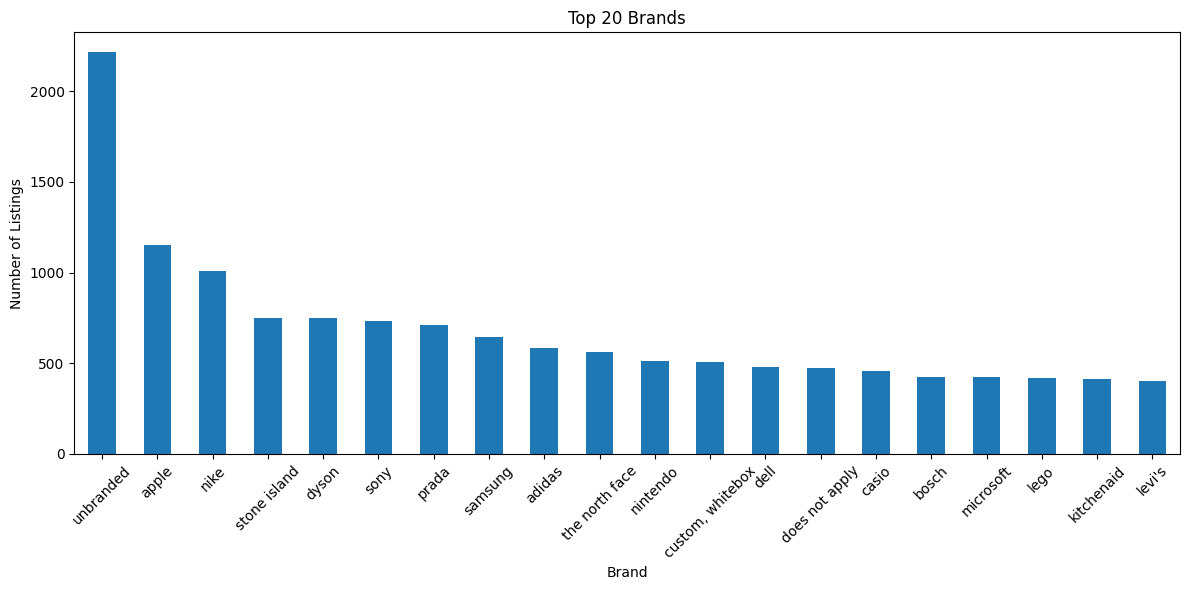

brand_name
unbranded           6.844953
apple               3.561601
nike                3.119493
stone island        2.315659
dyson               2.309476
sony                2.269284
prada               2.191993
samsung             1.994126
adidas              1.805534
the north face      1.737517
nintendo            1.589117
custom, whitebox    1.573659
dell                1.480909
does not apply      1.462359
casio               1.415984
bosch               1.307776
microsoft           1.307776
lego                1.298501
kitchenaid          1.270676
levi's              1.242851
Name: count, dtype: float64


In [71]:
import ast
import pandas as pd
import matplotlib.pyplot as plt

def extract_brand(x):
    if pd.isna(x):
        return None
    if hasattr(x, 'as_py'):
        x = x.as_py()
    if x is None:
        return None
    try:
        parsed = ast.literal_eval(str(x))
        return (parsed.get("name") or "").lower() or None
    except Exception:
        return str(x).lower() or None

df["brand_name"] = df["brand"].apply(extract_brand)

brand_series = df["brand_name"].value_counts()

brand_series.head(20).plot(kind="bar", figsize=(12, 6))
plt.title("Top 20 Brands")
plt.xlabel("Brand")
plt.ylabel("Number of Listings")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

brand_proportion = (brand_series / brand_series.sum()) * 100
print(brand_proportion.head(20))

In [72]:
import re

def clean_brand(brand):
    if pd.isna(brand) or str(brand).lower() in ["", "nan", "none", "unbranded", "branded"]:
        return "unbranded"
    brand = str(brand).lower()
    brand = re.sub(r"[®™©]", "", brand)
    brand = re.sub(r"\b(inc|corp|co|ltd|official store|store|brand)\b", "", brand)
    return brand.strip()

CATEGORY_RULES = {
    "electronics": [
        "apple", "samsung", "sony", "lg", "motorola", "nokia", "htc", "xiaomi", "oppo",
        "google", "microsoft", "asus", "acer", "dell", "hp", "lenovo", "beats", "bose",
        "jbl", "anker", "fitbit", "dyson", "ultimate ears", "soundcore", "harman kardon",
        "marshall", "uniwa", "kyocera", "oneplus", "razer", "logitech", "corsair",
        "turtlebox", "sonos", "tribit", "ue boom", "pantech", "tcl", "wiko",
        "viewsonic", "benq", "alienware", "msi",
        "western digital", "wd", "seagate", "sandisk", "kingston", "crucial",
        "samsung ssd", "sabrent", "sk hynix", "toshiba", "transcend",
    ],
    "cameras": [
        "canon", "nikon", "fujifilm", "fuji", "olympus", "leica", "pentax",
        "sigma", "hasselblad", "mamiya", "phase one", "godox", "yongnuo",
        "insta360", "dji", "gopro",
    ],
    "fashion": [
        "gucci", "prada", "louis vuitton", "chanel", "dior", "balenciaga", "versace",
        "fendi", "burberry", "tory burch", "zara", "h&m", "uniqlo", "nike", "adidas",
        "puma", "levis", "ralph lauren", "tommy hilfiger", "coach", "michael kors",
        "wrangler", "dooney & bourke", "jordan", "guess", "carhartt", "north face",
        "columbia", "patagonia", "under armour", "lululemon", "fossil", "ray-ban",
        "oakley", "vans", "converse", "new balance", "reebok", "timberland",
        # Genuine luxury fashion — handbags/scarves price like fashion, not watches
        "hermes", "bottega veneta",
    ],
    "gaming": [
        "playstation", "xbox", "nintendo", "atari", "sega", "activision", "ea sports",
        "ubisoft", "thq", "valve", "turbografx",
    ],
    "jewelry": [
        # Fine jewelry brands — most jewelry is unbranded so keywords do the work
        "pandora", "tiffany", "swarovski", "alex and ani", "david yurman",
        # High-value watches: price like jewelry, not like $1 trading cards
        "rolex", "omega", "tag heuer", "cartier", "bvlgari", "chopard",
        "patek philippe", "audemars piguet", "iwc", "breitling",
    ],
    "home_kitchen": [
        "kitchenaid", "breville", "delonghi", "cuisinart", "ninja", "instant pot",
        "keurig", "philips", "miele", "nespresso", "gourmia", "chefman", "presto",
        "bella", "whirlpool", "jura", "cosori", "outin", "mr. coffee", "shark",
        "roomba", "irobot", "waring", "pavoni", "gaggia",
    ],
    "tools": [
        "bosch", "dewalt", "makita", "milwaukee", "craftsman", "ryobi",
        "black & decker", "stanley", "ridgid", "metabo", "hikoki", "festool",
        "worx", "ego power", "greenworks",
    ],
    "sports": [
        "callaway", "taylormade", "titleist", "ping", "wilson", "bridgestone", "mizuno",
        "cleveland", "cobra", "odyssey", "scotty cameron", "footjoy", "srixon",
        "specialized", "trek", "giant bicycles", "cannondale", "scott bikes",
        "polaris", "acdelco",
    ],
    "health_beauty": [
        "gillette", "dove", "nivea", "olay", "neutrogena", "loreal",
        "revlon", "maybelline", "nyx", "mac cosmetics", "clinique", "estee lauder",
        "the ordinary", "cerave", "la roche-posay", "old spice", "axe",
    ],
    "garden": [
        "miracle-gro", "scotts", "husqvarna", "gardena",
    ],
    "music": [
        "fender", "gibson", "yamaha", "roland", "korg", "steinway", "shure",
        "audio-technica", "sennheiser", "technics", "rega", "pro-ject", "ortofon",
    ],
}

ITEM_KEYWORDS = {
    "cameras": [
        "mirrorless camera", "mirrorless", "dslr", "digital camera", "camera body",
        "camera kit", "camera lens", "telephoto lens", "wide angle lens", "prime lens",
        "full frame camera", "crop sensor", "micro four thirds", "medium format",
        "canon eos", "nikon d", "nikon z", "fuji x", "sony a7", "sony a6",
        "panasonic lumix", "olympus om", "speedlight", "flash gun", "camera flash",
        "neutral density filter", "nd filter", "camera tripod", "gimbal stabilizer",
    ],
    "health_beauty": [
        "shave gel", "shaving gel", "shaving cream", "shaving foam", "aftershave",
        "shave balm", "razor blade", "safety razor", "straight razor", "cartridge razor",
        "face cream", "moisturiser", "moisturizer", "serum", "toner",
        "cologne", "perfume", "eau de toilette", "fragrance", "body spray",
        "lip balm", "lip gloss", "mascara", "foundation", "concealer", "eyeshadow",
        "nail polish", "hair dye", "hair serum", "conditioner", "shampoo",
        "sunscreen", "spf", "body lotion", "body wash",
    ],
    "garden": [
        "garden hose", "garden hose reel", "garden nozzle", "garden sprayer",
        "plant pot", "flower pot", "plant stand", "planter box", "raised bed",
        "seed packet", "flower seed", "vegetable seed", "grow light", "led grow",
        "garden decor", "garden sculpture", "garden ornament", "garden light",
        "solar light", "led solar", "solar garden", "outdoor solar",
        "compost bin", "garden waste", "greenhouse",
        "garden fork", "garden spade", "garden hoe", "garden rake",
        "watering can", "sprinkler", "drip irrigation",
        "garden plant", "indoor plant", "outdoor plant", "house plant",
    ],
    "electronics": [
        "iphone", "ipad", "macbook", "airpods", "galaxy s", "galaxy a", "galaxy tab",
        "pixel phone", "pixel watch", "smartphone", "android phone", "android",
        "dual sim", "unlocked phone", "prepaid phone", "flip phone", "5g phone",
        "cell phone", "lte phone",
        "bluetooth speaker", "portable speaker", "wireless speaker", "waterproof speaker",
        "outdoor speaker", "stereo speaker", "speaker system",
        "earbuds", "earphones", "headphones", "soundbar", "subwoofer", "boombox",
        "gaming monitor", "curved monitor", "4k monitor", "led monitor",
        "lcd monitor", "ips monitor", "portable monitor", "computer monitor",
        "smartwatch", "fitness tracker", "smart tv", "laptop", "chromebook",
        "gaming laptop", "tablet pc", "e-reader", "kindle",
        "mechanical keyboard", "usb hub", "charging dock",
        "graphics card", "gpu", "rtx", "gtx", "rx 6", "rx 7",
        "intel core", "amd ryzen", "cpu",
        "motherboard", "ddr4", "ddr5", "gb ram",
        "ssd", "solid state drive", "nvme", "m.2 ssd", "pcie ssd",
        "internal ssd", "external ssd", "usb flash drive", "memory card",
        "hard drive", "hdd", "external hard drive", "nas",
    ],
    "gaming": [
        "playstation", "ps5", "ps4", "ps3", "ps vita", "xbox one", "xbox series",
        "nintendo switch", "nintendo 3ds", "game boy", "gamecube", "wii",
        "gaming console", "retro console", "handheld console", "analogue pocket",
        "video game", "pc game", "steam deck",
    ],
    "fashion": [
        "jeans", "hoodie", "tracksuit", "joggers", "leggings", "jacket", "blazer",
        "cardigan", "blouse", "dress", "sneakers", "trainers", "boots", "heels",
        "handbag", "tote bag", "crossbody bag", "backpack", "purse", "wallet",
        "sunglasses", "belt", "scarf",
    ],
    "furniture": [
        "sofa", "couch", "armchair", "recliner", "sectional sofa", "sleeper sofa",
        "sofa bed", "loveseat", "chaise lounge",
        "dining table", "coffee table", "side table", "end table", "console table",
        "dining chair", "bar stool", "office chair", "desk chair", "gaming chair",
        "wardrobe", "chest of drawers", "dresser", "nightstand", "bedside table",
        "bookcase", "bookshelf", "shelving unit", "display cabinet", "tv stand",
        "bed frame", "headboard", "platform bed", "ottoman", "footstool",
        "patio furniture", "garden furniture", "outdoor furniture",
    ],
    "tools": [
        "power drill", "cordless drill", "hammer drill", "impact driver",
        "circular saw", "jigsaw", "reciprocating saw", "miter saw", "table saw",
        "angle grinder", "belt sander", "orbital sander", "router",
        "heat gun", "oscillating tool", "multi-tool", "nail gun",
        "crossline laser", "laser level", "line laser", "spirit level",
        "tape measure", "measuring tape",
        "workbench", "tool kit", "socket set", "screwdriver set", "wrench set",
        "pliers set", "hex key", "allen key",
        "lawn mower", "hedge trimmer", "leaf blower", "pressure washer", "chainsaw",
    ],
    "home_kitchen": [
        "espresso machine", "coffee maker", "air fryer", "slow cooker", "instant pot",
        "pressure cooker", "stand mixer", "rice cooker", "waffle maker", "toaster",
        "microwave oven", "vacuum cleaner", "robot vacuum", "steam mop",
        "food processor", "blender", "juicer", "electric kettle",
        "fryer", "deep fryer",
    ],
    "sports": [
        "golf club", "golf bag", "golf balls", "golf rangefinder", "golf glove",
        "golf shoes", "golf cart", "putting mat", "swing trainer",
        "golf driver", "fairway wood", "iron set", "golf wedge",
        "putter", "wedge", "golf grip", "shaft graphite", "shaft stiff",
        "tennis racket", "football boots", "cycling helmet", "yoga mat", "dumbbell",
        "weight plate", "resistance band", "treadmill", "exercise bike",
        "mountain bike", "road bike", "bmx bike", "bicycle", "bike frame",
        "cycling jersey", "cycling shoes", "bike saddle",
    ],
    "music": [
        "vinyl record", "vinyl lp", "lp record", "33 rpm", "45 rpm", "78 rpm",
        "vinyl album", "12 inch vinyl", "7 inch vinyl", "record collection",
        "record player", "turntable", "phono cartridge", "stylus needle",
        "electric guitar", "acoustic guitar", "bass guitar", "guitar amplifier",
        "keyboard synthesizer", "drum kit", "snare drum", "cymbal",
        "sheet music", "music stand",
    ],
    "books": [
        "hardcover", "paperback", "novel", "textbook", "first edition", "signed copy",
        "graphic novel", "manga", "comic book", "book set", "box set books",
    ],
    "jewelry": [
        # Fine jewelry brands — most jewelry is unbranded so keywords do the work
        "pandora", "tiffany", "swarovski", "alex and ani", "david yurman",
        # High-value watches: price like jewelry, not like $1 trading cards
        "rolex", "omega", "tag heuer", "cartier", "bvlgari", "chopard",
        "patek philippe", "audemars piguet", "iwc", "breitling",
    ],
}

BRAND_MAP = {brand: cat for cat, brands in CATEGORY_RULES.items() for brand in brands}


In [73]:
print(set(df['brand_name'].tolist()))

{'top landing', 'john smedley', 'canyon', 'republic', 'saeco, starbucks barista', 'metrowear', 'plain pockets', 'us', 'st johns bay', 'bakscape', 'lazaro', 'raven', 'verizon', 'agolde', 'the perfect jean nyc', 'bykitchen', 'milwaukee', 'windsor', 'toshiba/ seagate', 'crowood', 'aeboren', "t's pc's", 'retroid', 'mastercraft', 'korg', 'department 56', 'goody products, inc.', 'made in japan', '925silver_lover', 'uplift desk', 'adventon', "chateau d'ax", 'symetrix', 'gypsy blu', 'gdrasuya10', 'unbranded, milor, marvella, coro, joan rivers, the limited, lisner, innovative time virtual pet game watch', 'roberto cavalli', 'home it', 'hewlett packard enterprise', 'maze speed', 'feliz home', 'longchamp', 'vinsetto', 'bic', 'tempo paris', 'fas', 'fch', 'stakt', 'vasagle', 'palace learning', 'gentle monster', 'anmecs', 'pimpernel', 'polar', 'h.c. wentworth & son', 'kenzies of london', 'actn alpha country training nutrition', 'ysl', 'troy lee designs', 'puritan', 'linda farrow', 'garden of life', 

category
other            40795
electronics      10657
fashion           9475
sports            2450
home_kitchen      2327
gaming            1740
furniture         1429
tools             1026
music              856
books              666
health_beauty      576
cameras            524
garden             111
jewelry             75
Name: count, dtype: int64

category
other            56.1%
electronics      14.7%
fashion          13.0%
sports            3.4%
home_kitchen      3.2%
gaming            2.4%
furniture         2.0%
tools             1.4%
music             1.2%
books             0.9%
health_beauty     0.8%
cameras           0.7%
garden            0.2%
jewelry           0.1%
Name: proportion, dtype: str


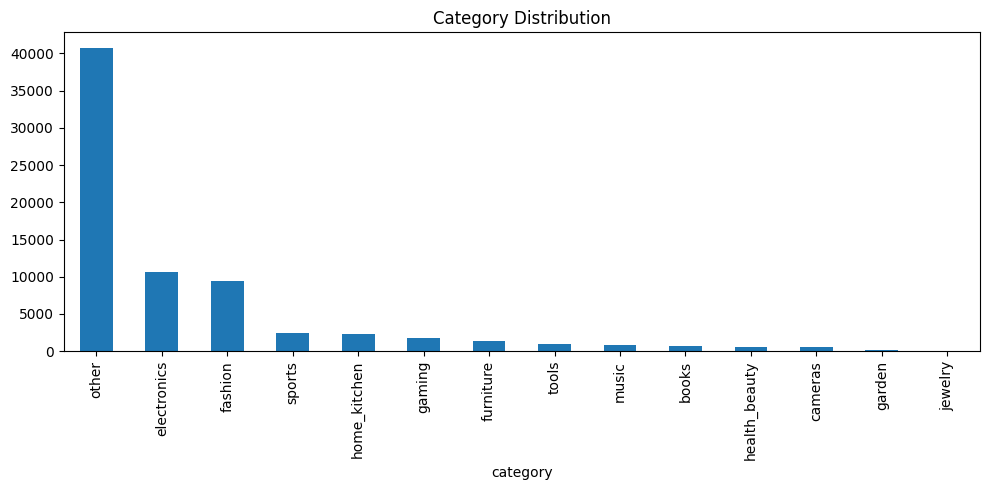

In [74]:
def assign_category_final(row):
    title_txt = str(row['title']).lower() if pd.notna(row['title']) else ""
    desc_txt  = str(row['description']).lower() if pd.notna(row['description']) else ""
    # brand_name is already a clean lowercase string extracted by extract_brand()
    brand_name = str(row['brand_name']).lower() if pd.notna(row['brand_name']) else ""

    # 1. Extracted brand column → BRAND_MAP (highest confidence)
    if brand_name and brand_name not in ("nan", "none", "unbranded", ""):
        cat = BRAND_MAP.get(brand_name)
        if cat:
            return cat

    # 2. Any known brand name found inside the listing title
    #    catches "Apple iPhone 13 Pro" when brand column is empty
    for brand, cat in BRAND_MAP.items():
        if brand in title_txt:
            return cat

    # 3. Keyword scan of title + description
    combined = title_txt + " " + desc_txt
    if combined.strip():
        for cat, keywords in ITEM_KEYWORDS.items():
            if any(k in combined for k in keywords):
                return cat

    return "other"

df["brand_clean"] = df["brand_name"].apply(lambda x: clean_brand(x) if pd.notna(x) else "unbranded")
df["category"] = df.apply(assign_category_final, axis=1)

print(df["category"].value_counts())
print()
print(df["category"].value_counts(normalize=True).mul(100).round(1).astype(str) + "%")

df["category"].value_counts().plot(kind="bar", figsize=(10, 5))
plt.title("Category Distribution")
plt.tight_layout()
plt.show()

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 10376.70it/s]


Starting 'other' count: 40,795


Batches: 100%|██████████| 638/638 [00:15<00:00, 41.25it/s]


After title pass: 31,338 still 'other' — trying description...


Batches: 100%|██████████| 490/490 [00:10<00:00, 46.78it/s]


After description pass: 30,141 still 'other'

category
other            30141
fashion          11692
electronics      10863
sports            3133
jewelry           2975
home_kitchen      2605
gaming            1960
furniture         1841
collectibles      1795
music             1525
tools             1199
books             1169
health_beauty      870
cameras            641
garden             298
Name: count, dtype: int64

category
other            41.5%
fashion          16.1%
electronics      14.9%
sports            4.3%
jewelry           4.1%
home_kitchen      3.6%
gaming            2.7%
furniture         2.5%
collectibles      2.5%
music             2.1%
tools             1.6%
books             1.6%
health_beauty     1.2%
cameras           0.9%
garden            0.4%
Name: proportion, dtype: str


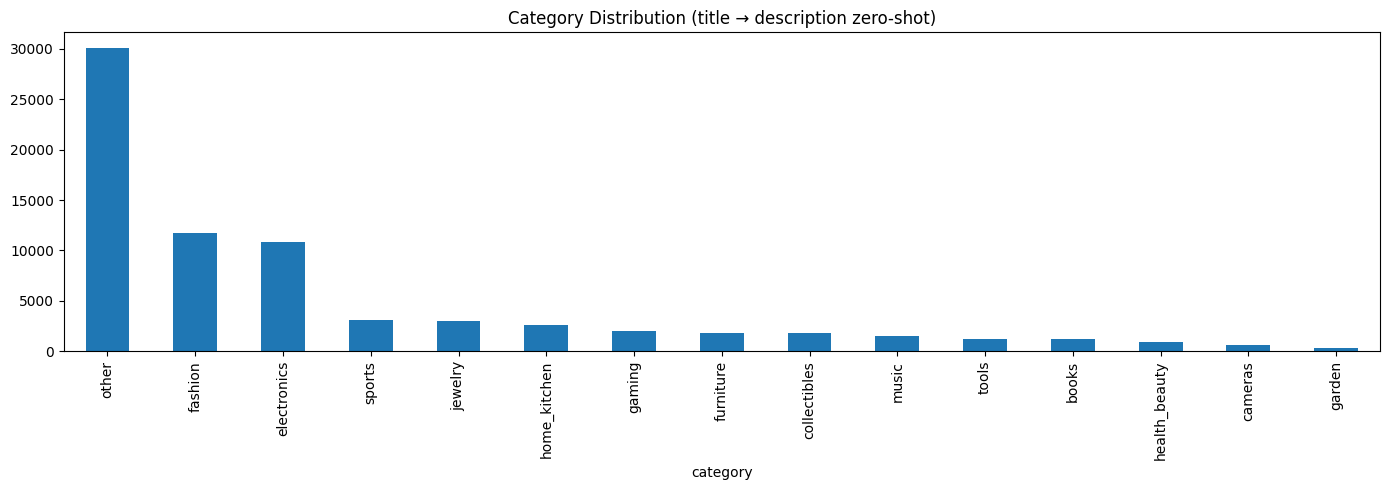

In [75]:
from sentence_transformers import SentenceTransformer, util
import torch
import numpy as np

CATEGORY_DESCRIPTIONS = {
    "cameras":       "mirrorless camera dslr digital camera camera body lens telephoto wide angle full frame canon eos nikon sony alpha fuji panasonic lumix olympus speedlight flash gimbal tripod",
    "jewelry":       "sterling silver ring earring necklace bracelet pendant gemstone handmade jewelry turquoise amethyst moonstone labradorite pearl diamond gold silver vintage jewelry ethnic native american jewelry set casio watch vintage watch analog watch g-shock",
    "health_beauty": "shaving cream shave gel aftershave razor blade safety razor straight razor face cream moisturiser serum cologne perfume fragrance body lotion lip balm mascara foundation sunscreen skincare grooming",
    "garden":        "garden plant indoor plant outdoor plant flower pot planter raised bed seed garden hose watering can sprinkler compost greenhouse solar light garden decor garden ornament grow light gardening",
    "electronics":   "bluetooth speaker portable wireless speaker smartphones iphones android phones laptops macbooks tablets earbuds airpods headphones smartwatches gaming monitor lcd monitor led monitor computer screen display graphics card gpu processor cpu ssd nvme solid state drive hard drive ram motherboard",
    "gaming":        "video game consoles PlayStation Xbox Nintendo Switch game boy retro consoles handheld gaming video games PC games steam deck gaming accessories controllers",
    "fashion":       "clothing jeans hoodies jackets dresses sneakers trainers boots shoes handbags purses wallets sunglasses sportswear streetwear designer clothing accessories backpack",
    "furniture":     "sofa couch armchair recliner sectional sofa sleeper sofa dining table coffee table office chair desk chair wardrobe chest of drawers bookcase bed frame headboard ottoman bar stool patio furniture outdoor furniture living room bedroom",
    "tools":         "power drill cordless drill circular saw jigsaw angle grinder sander router crossline laser laser level impact driver nail gun heat gun bosch dewalt makita milwaukee lawn mower hedge trimmer pressure washer chainsaw",
    "home_kitchen":  "kitchen appliances coffee machines espresso makers air fryers slow cookers stand mixers vacuum cleaners robot vacuums toasters microwaves blenders food processors electric kettles fryer deep fryer",
    "sports":        "golf clubs putter wedge driver fairway wood iron set golf bags golf balls tennis rackets football boots cycling gear gym equipment dumbbells treadmills exercise bikes yoga mats mountain bike road bike bicycle cycling",
    "music":         "vinyl record lp record turntable record player 33rpm 45rpm vinyl album electric guitar acoustic guitar bass guitar amplifier keyboard synthesizer drum kit sheet music phono cartridge stylus",
    "books":         "books novels hardcover paperback textbooks first edition graphic novels manga comic books box set signed books children books",
    "collectibles":  "trading cards pokemon cards sports cards action figures funko pop diecast models vintage toys signed memorabilia stamps coins limited edition rare collectibles marvel comics lego set star wars figure hot wheels luxury watch rolex omega",
}

THRESHOLD = 0.22

model      = SentenceTransformer("all-MiniLM-L6-v2")
cat_names  = list(CATEGORY_DESCRIPTIONS.keys())
cat_embeds = model.encode(list(CATEGORY_DESCRIPTIONS.values()),
                          convert_to_tensor=True, normalize_embeddings=True)

def zero_shot_pass(texts, label=""):
    embeds = model.encode(texts, convert_to_tensor=True, normalize_embeddings=True,
                          batch_size=64, show_progress_bar=bool(label))
    sims   = util.cos_sim(embeds, cat_embeds)
    return sims.argmax(dim=1).cpu().numpy(), sims.max(dim=1).values.cpu().numpy()

other_mask = df["category"] == "other"
print(f"Starting 'other' count: {other_mask.sum():,}")

titles    = df.loc[other_mask, "title"].fillna("").astype(str).tolist()
idx1, sc1 = zero_shot_pass(titles, label="Stage 1 — title")
assigned1 = [cat_names[i] if s >= THRESHOLD else "other" for i, s in zip(idx1, sc1)]
df.loc[other_mask, "category"] = assigned1

other_mask2 = df["category"] == "other"
print(f"After title pass: {other_mask2.sum():,} still 'other' — trying description...")

descs = (df.loc[other_mask2, "description"]
           .fillna("").astype(str)
           .str.split().str[:100].str.join(" ").tolist())
idx2, sc2 = zero_shot_pass(descs, label="Stage 2 — description")
assigned2 = [cat_names[i] if s >= THRESHOLD else "other" for i, s in zip(idx2, sc2)]
df.loc[other_mask2, "category"] = assigned2

print(f"After description pass: {(df['category'] == 'other').sum():,} still 'other'\n")
print(df["category"].value_counts())
print()
print(df["category"].value_counts(normalize=True).mul(100).round(1).astype(str) + "%")

df["category"].value_counts().plot(kind="bar", figsize=(14, 5))
plt.title("Category Distribution (title → description zero-shot)")
plt.tight_layout()
plt.show()


In [76]:
import re
from wordcloud import STOPWORDS

other_mask = df['category'] == 'other'

text      = ' '.join(str(t) for t in df.loc[other_mask, 'title'].fillna(''))
#desc_text = ' '.join(str(t) for t in df.loc[other_mask, 'description'].fillna(''))
#text += ' ' + desc_text

text = re.sub(r'[^A-Za-z\s]', '', text).lower()

stopwords = set(STOPWORDS)
text = ' '.join(word for word in text.split() if word not in stopwords)

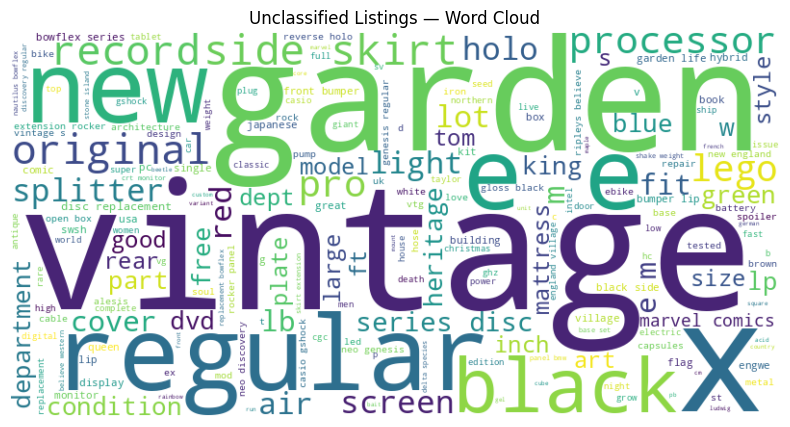

In [77]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Unclassified Listings — Word Cloud")
plt.show()

In [78]:
from sklearn.linear_model import LinearRegression

# Only real numeric features available at this stage — VIF on the full
# engineered feature matrix should be re-run in the preprocessing notebook.
numerical_cols = ["description_length", "image_count"]

def calculate_vif(df, features):
    """VIF_i = 1 / (1 - R²_i), R²_i from regressing feature_i on all others."""
    vif_data = []
    X = df[features].to_numpy(dtype=float)

    for i, feat in enumerate(features):
        X_other = np.delete(X, i, axis=1)
        y_feat  = X[:, i]

        mask = ~np.isnan(y_feat) & ~np.any(np.isnan(X_other), axis=1)
        if mask.sum() < 10:
            vif_data.append({"Feature": feat, "VIF": np.nan, "R²": np.nan})
            continue

        lr = LinearRegression()
        lr.fit(X_other[mask], y_feat[mask])
        r2  = lr.score(X_other[mask], y_feat[mask])
        vif = 1 / (1 - r2) if r2 < 1 else float("inf")
        vif_data.append({"Feature": feat, "VIF": round(vif, 2), "R²": round(r2, 4)})

    return pd.DataFrame(vif_data).sort_values("VIF", ascending=False)


vif_df = calculate_vif(df, df.select_dtypes(include=[np.number]).columns.tolist())
vif_df["Status"] = vif_df["VIF"].apply(
    lambda x: "VERY HIGH (>10)" if x > 10 else
              "HIGH (5-10)"     if x > 5  else
              "MODERATE (2-5)"  if x > 2  else
              "LOW (<2)"
)

print("VARIANCE INFLATION FACTOR ANALYSIS")
print("=" * 70)
print(vif_df.to_string(index=False))
print("\nNote: only 2 raw numeric features exist pre-preprocessing.")
print("Re-run on the full feature matrix in the preprocessing notebook.")

VARIANCE INFLATION FACTOR ANALYSIS
           Feature  VIF  R²   Status
       subcategory  NaN NaN LOW (<2)
description_length  NaN NaN LOW (<2)
       image_count  NaN NaN LOW (<2)

Note: only 2 raw numeric features exist pre-preprocessing.
Re-run on the full feature matrix in the preprocessing notebook.


Rows with price data: 42,564

Price summary by category (USD):
               count  median    mean     std     p25     p75       max
category                                                              
cameras          641  529.95  739.41  856.19  229.99  969.99   7590.00
electronics    10861  159.24  296.95  501.90   54.00  350.00  16520.00
sports          3133   79.99  254.41  658.13   29.99  203.99  13425.57
furniture       1841   73.37  263.22  590.68   24.36  235.00   6800.00
home_kitchen    2605   55.81  143.85  328.05   25.00  145.00   8078.63
gaming          1960   45.00  109.71  266.67   19.99  129.43   7500.00
fashion        11692   39.99   98.85  266.55   20.00   90.00  10466.56
tools           1199   39.99   75.96  127.73   17.99   80.00   1950.00
music           1525   39.88  118.75  309.17   15.00  109.99   8000.00
jewelry         2975   32.00   97.19  252.07   13.50   85.00   5350.00
health_beauty    870   20.40   35.94   52.14   12.50   35.00    562.50
collectibles  

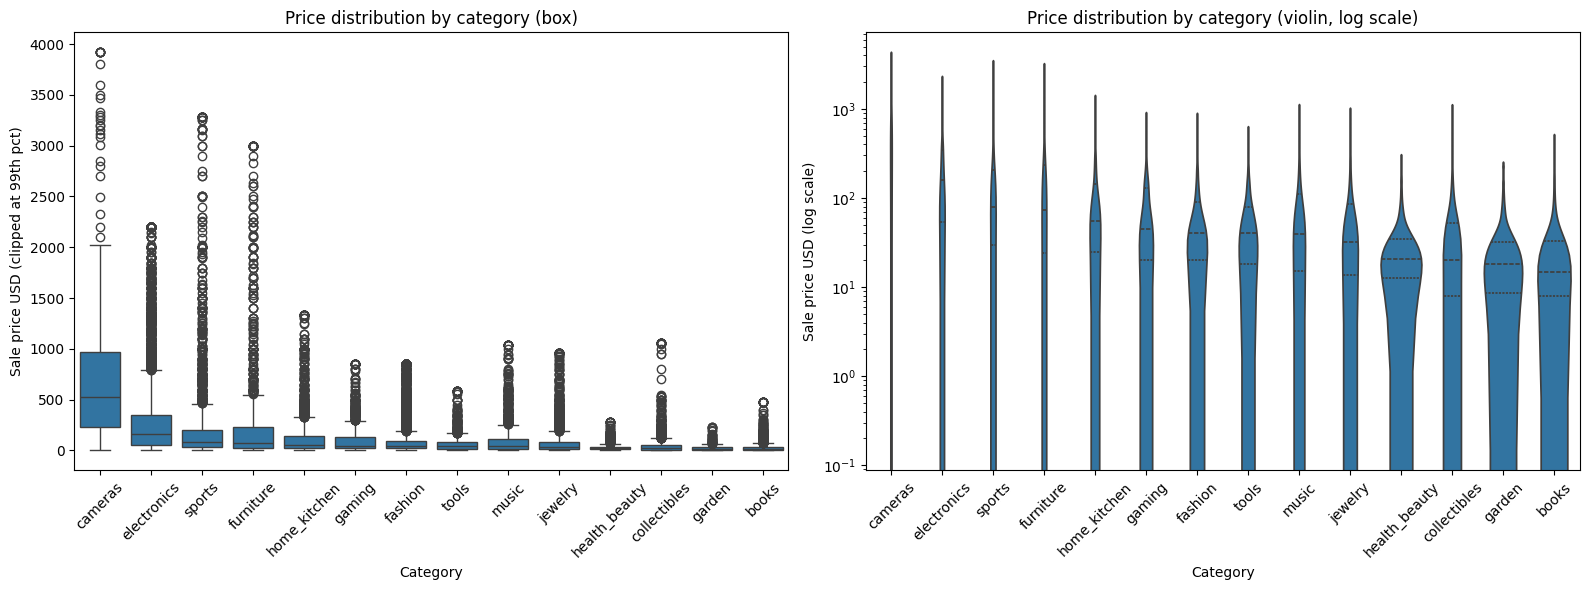

In [79]:
import seaborn as sns

# ── Price distribution per category ──────────────────────────────────────────
# price_df built in earlier cell from big_ebay_search_results.csv

cat_price = (
    df[["listing_url", "category"]]
    .merge(price_df, on="listing_url", how="inner")
    .query("category != 'other' and sale_price > 0")
)

# Clip per-category at 99th percentile so outliers don't flatten the plots
cat_price["sale_price_clipped"] = cat_price.groupby("category")["sale_price"].transform(
    lambda s: s.clip(upper=s.quantile(0.99))
)

print(f"Rows with price data: {len(cat_price):,}\n")

# ── Summary statistics ────────────────────────────────────────────────────────
summary = (
    cat_price.groupby("category")["sale_price"]
    .agg(
        count="count",
        median="median",
        mean="mean",
        std="std",
        p25=lambda s: s.quantile(0.25),
        p75=lambda s: s.quantile(0.75),
        max="max",
    )
    .round(2)
    .sort_values("median", ascending=False)
)
print("Price summary by category (USD):")
print(summary.to_string())

order = summary.index.tolist()

# ── Plots ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.boxplot(
    data=cat_price, x="category", y="sale_price_clipped",
    order=order, ax=axes[0],
)
axes[0].set_title("Price distribution by category (box)")
axes[0].set_xlabel("Category")
axes[0].set_ylabel("Sale price USD (clipped at 99th pct)")
axes[0].tick_params(axis="x", rotation=45)

sns.violinplot(
    data=cat_price, x="category", y="sale_price_clipped",
    order=order, ax=axes[1], inner="quartile",
)
axes[1].set_yscale("log")
axes[1].set_title("Price distribution by category (violin, log scale)")
axes[1].set_xlabel("Category")
axes[1].set_ylabel("Sale price USD (log scale)")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

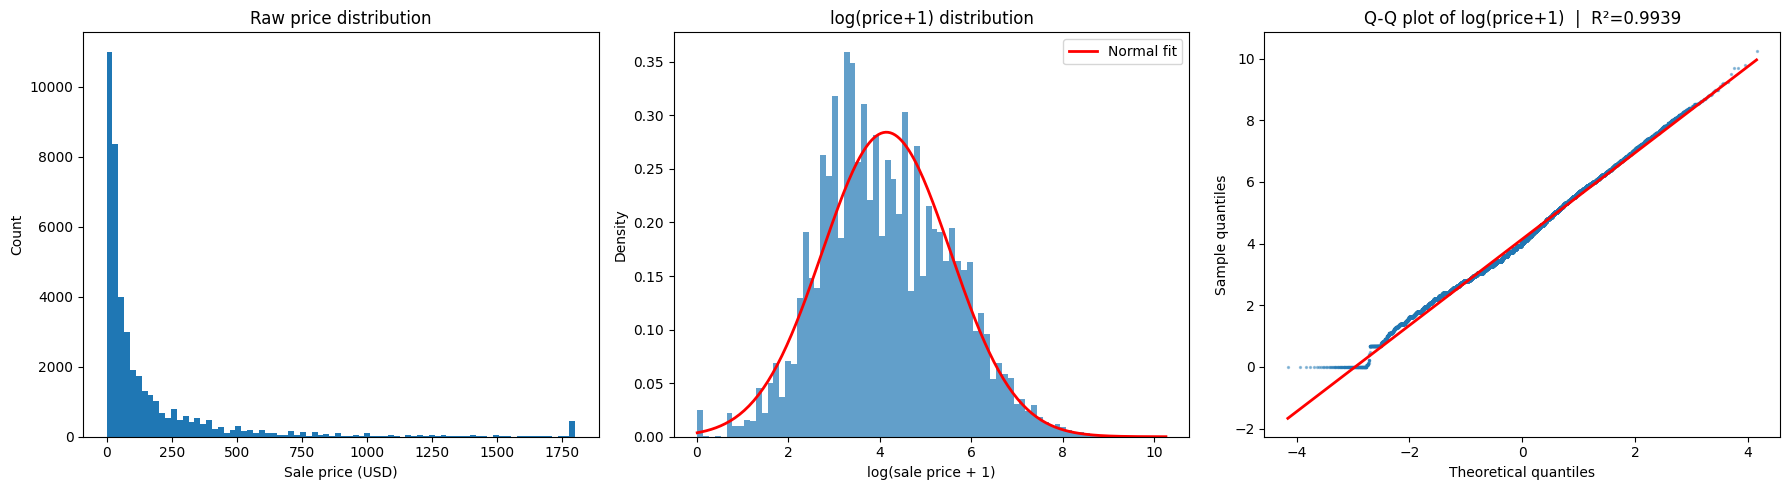

Shapiro-Wilk on log(price+1) sample (n=5,000): W=0.9951, p=0.0000

Skewness — raw price: 15.87   log(price+1): 0.21

log(price+1) is approximately normal → train XGBoost on log(price+1), exponentiate predictions.


In [80]:
from scipy import stats

prices = cat_price["sale_price"].dropna()
log_prices = np.log1p(prices)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── Raw price histogram ───────────────────────────────────────────────────────
axes[0].hist(prices.clip(upper=prices.quantile(0.99)), bins=80, edgecolor="none")
axes[0].set_title("Raw price distribution")
axes[0].set_xlabel("Sale price (USD)")
axes[0].set_ylabel("Count")

# ── Log price histogram with normal curve overlay ─────────────────────────────
mu, sigma = log_prices.mean(), log_prices.std()
x = np.linspace(log_prices.min(), log_prices.max(), 200)
axes[1].hist(log_prices, bins=80, density=True, edgecolor="none", alpha=0.7)
axes[1].plot(x, stats.norm.pdf(x, mu, sigma), "r-", linewidth=2, label="Normal fit")
axes[1].set_title("log(price+1) distribution")
axes[1].set_xlabel("log(sale price + 1)")
axes[1].set_ylabel("Density")
axes[1].legend()

# ── Q-Q plot ──────────────────────────────────────────────────────────────────
(osm, osr), (slope, intercept, r) = stats.probplot(log_prices, dist="norm")
axes[2].scatter(osm, osr, s=2, alpha=0.4)
axes[2].plot(
    [osm[0], osm[-1]],
    [slope * osm[0] + intercept, slope * osm[-1] + intercept],
    "r-", linewidth=2,
)
axes[2].set_title(f"Q-Q plot of log(price+1)  |  R²={r**2:.4f}")
axes[2].set_xlabel("Theoretical quantiles")
axes[2].set_ylabel("Sample quantiles")

plt.tight_layout()
plt.show()

# ── Shapiro-Wilk on a sample (test breaks down on large N) ────────────────────
sample = log_prices.sample(min(5000, len(log_prices)), random_state=42)
stat, p = stats.shapiro(sample)
print(f"Shapiro-Wilk on log(price+1) sample (n={len(sample):,}): W={stat:.4f}, p={p:.4f}")
print()
skew_raw = float(prices.skew())
skew_log = float(log_prices.skew())
print(f"Skewness — raw price: {skew_raw:.2f}   log(price+1): {skew_log:.2f}")
print()
if abs(skew_log) < 1:
    print("log(price+1) is approximately normal → train XGBoost on log(price+1), exponentiate predictions.")
else:
    print("log(price+1) still skewed — consider further transformation or train on raw price with quantile loss.")

# Preprocessing

Steps performed before feature engineering:
1. Merge `sale_price` onto the main dataframe
2. Filter invalid rows (failed scrapes, missing title, no price, unclassified)
3. Deduplicate on `listing_url`
4. Extract `condition` from `raw_item_specifics_json` (source column is 99.98% null)
5. Clip price outliers per category at 99th percentile
6. Save clean checkpoint to parquet

In [81]:
# ── Step 1: Merge sale_price ──────────────────────────────────────────────────
price_lookup = price_df.drop_duplicates("listing_url")

clean = df.merge(price_lookup, on="listing_url", how="left")
print(f"Rows after merge:            {len(clean):,}")

# ── Step 2: Filter invalid rows ───────────────────────────────────────────────
before = len(clean)

clean = clean[clean["category"] != "other"]
print(f"Dropped 'other' category:    {before - len(clean):,}  →  {len(clean):,} rows")
before = len(clean)

clean = clean[clean["detail_error"].isna()]
print(f"Dropped failed scrapes:      {before - len(clean):,}  →  {len(clean):,} rows")
before = len(clean)

clean = clean[clean["title"].notna()]
print(f"Dropped missing titles:      {before - len(clean):,}  →  {len(clean):,} rows")
before = len(clean)

clean = clean[clean["sale_price"].notna() & (clean["sale_price"] > 0)]
print(f"Dropped missing/zero price:  {before - len(clean):,}  →  {len(clean):,} rows")

# ── Step 3: Deduplicate ───────────────────────────────────────────────────────
before = len(clean)
clean = clean.drop_duplicates(subset="listing_url")
print(f"Dropped duplicate URLs:      {before - len(clean):,}  →  {len(clean):,} rows")

print(f"\nClean dataset: {len(clean):,} rows across {clean['category'].nunique()} categories")
print(clean["category"].value_counts())

Rows after merge:            72,707
Dropped 'other' category:    30,141  →  42,566 rows
Dropped failed scrapes:      0  →  42,566 rows
Dropped missing titles:      690  →  41,876 rows
Dropped missing/zero price:  2  →  41,874 rows
Dropped duplicate URLs:      0  →  41,874 rows

Clean dataset: 41,874 rows across 14 categories
category
fashion          11527
electronics      10676
sports            3099
jewelry           2919
home_kitchen      2522
gaming            1927
furniture         1836
collectibles      1744
music             1518
tools             1180
books             1145
health_beauty      864
cameras            621
garden             296
Name: count, dtype: int64


In [82]:
# ── Step 4: Extract condition from raw_item_specifics_json ────────────────────
# The `condition` column is 99.98% null. The condition label is encoded in the
# KEY of the raw JSON, e.g. {"condition new": "A brand-new..."} → "new"

CONDITION_MAP = {
    "new":                        "new",
    "open box":                   "open_box",
    "certified refurbished":      "refurbished",
    "excellent refurbished":      "refurbished",
    "very good refurbished":      "refurbished",
    "good refurbished":           "refurbished",
    "seller refurbished":         "refurbished",
    "used":                       "used",
    "for parts or not working":   "for_parts",
}

def extract_condition(raw_json):
    if pd.isna(raw_json):
        return None
    try:
        d = ast.literal_eval(builtins.str(raw_json))
        for key in d.keys():
            k = key.lower()
            if k.startswith("condition"):
                label = k.replace("condition", "").strip()
                return CONDITION_MAP.get(label, label) if label else None
    except Exception:
        pass
    return None

clean["condition_clean"] = clean["raw_item_specifics_json"].apply(extract_condition)

print("Condition distribution:")
print(clean["condition_clean"].value_counts(dropna=False))
print(f"\nCondition fill rate: {clean['condition_clean'].notna().mean():.1%}")

Condition distribution:
condition_clean
NaN                                         14205
used                                         7242
new                                          6721
pre-owned - good                             2830
pre-owned - excellent                        2597
new with tags                                2582
open_box                                      890
new without tags                              862
for_parts                                     459
very good                                     411
good                                          332
new with box and papers                       291
new with box                                  277
brand new                                     255
like new                                      241
pre-owned - fair                              228
pre-owned                                     207
new with packaging                            159
new without box                               142
ungraded -

In [83]:
# ── Step 5: Clip price outliers per category at 99th percentile ──────────────
p99 = clean.groupby("category")["sale_price"].transform(lambda s: s.quantile(0.99))
before = len(clean)
clean = clean[clean["sale_price"] <= p99].copy()
print(f"Dropped price outliers (above per-category 99th pct): {before - len(clean):,} rows")
print(f"Remaining: {len(clean):,} rows")
print()
print("Price range after clipping:")
print(clean.groupby("category")["sale_price"].agg(["min", "median", "max"]).round(2))

# ── Step 6: Coerce mixed-type object columns before saving ───────────────────
# Merging CSVs can leave columns like item_number as mixed float/str (object).
# PyArrow rejects these — cast all object columns to str, preserving NaN as pd.NA.
obj_cols = clean.select_dtypes(include="object").columns
for col in obj_cols:
    if clean[col].map(type).nunique() > 1:
        clean[col] = clean[col].where(clean[col].isna(), clean[col].astype(str))

# ── Step 7: Save clean checkpoint ─────────────────────────────────────────────
clean.to_parquet("output/clean.parquet", index=False)
print(f"\nSaved → output/clean.parquet  ({len(clean):,} rows, {clean.shape[1]} columns)")


Dropped price outliers (above per-category 99th pct): 420 rows
Remaining: 41,454 rows

Price range after clipping:
                min  median      max
category                            
books          0.99   14.00   400.00
cameras        0.99  518.64  3800.00
collectibles   0.01   19.99  1000.00
electronics    0.01  155.00  2200.00
fashion        0.01   39.88   850.00
furniture      0.99   70.00  3000.00
gaming         0.99   44.99   800.00
garden         0.99   18.00   224.99
health_beauty  0.99   20.00   280.00
home_kitchen   0.99   53.94  1329.90
jewelry        0.01   30.99   950.00
music          0.99   38.37   995.00
sports         0.49   79.00  3299.95
tools          0.15   39.96   585.00


/var/folders/hq/v_7wt_d51sn37zqs9vlsf41c0000gn/T/ipykernel_51656/3263166448.py:14: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  obj_cols = clean.select_dtypes(include="object").columns



Saved → output/clean.parquet  (41,454 rows, 21 columns)


# Feature Engineering

## 1. Comparable listing stats (leave-one-out)

For each item, compute price statistics from every *other* item in the same
comparable group — excluding the item itself to prevent data leakage.

**Comparable key:** `category | brand | condition`
Unbranded items fall back to `category | condition` since there is no brand signal.

If a group has only 1 item (no comparables), stats are filled from the broader
`category | condition` group, then from the category median as a last resort.

In [85]:
# ── Subcategory tokens for high-variance categories ──────────────────────────
# Groups items within cameras/furniture/sports/music by type so the comparable
# price stats compare like-for-like (lens vs body, sofa vs table, etc.)
SUBCATEGORY_TOKENS = {
    "cameras": [
        (["camera body", "body only", "body cap", "mirrorless body", "dslr body"], "body"),
        (["lens", " mm ", "telephoto", "wide angle", "prime lens", "zoom lens", "macro lens"], "lens"),
        (["flash", "speedlight", "strobe", "flashgun"], "flash"),
        (["tripod", "filter", "nd filter", "camera bag", "camera strap", "gimbal"], "accessory"),
    ],
    "furniture": [
        (["sofa", "couch", "loveseat", "sectional", "recliner", "armchair", "chaise"], "sofa"),
        (["dining table", "coffee table", "side table", "console table", "end table", "desk"], "table"),
        (["dining chair", "bar stool", "office chair", "desk chair", "gaming chair"], "chair"),
        (["wardrobe", "drawers", "dresser", "cabinet", "shelv", "bookcase", "bookshelf", "tv stand"], "storage"),
        (["bed frame", "headboard", "mattress", "ottoman", "footstool"], "bed"),
        (["patio", "garden furniture", "outdoor furniture"], "outdoor"),
    ],
    "sports": [
        (["golf", "putter", "wedge", "iron", "driver", "fairway", "golf club", "shaft"], "golf"),
        (["mountain bike", "road bike", "bicycle", "bike frame", "cycling", "bmx"], "cycling"),
        (["dumbbell", "weight plate", "barbell", "kettlebell", "resistance band", "treadmill", "exercise bike"], "gym"),
        (["tennis", "badminton", "squash", "racket"], "racket"),
        (["yoga", "pilates", "mat"], "yoga"),
    ],
    "music": [
        (["vinyl", "lp", "record", "33 rpm", "45 rpm", "turntable", "record player"], "vinyl"),
        (["guitar", "bass guitar", "electric guitar", "acoustic guitar"], "guitar"),
        (["piano", "keyboard", "synthesizer", "korg", "roland"], "keys"),
        (["drum", "cymbal", "snare", "percussion"], "drums"),
        (["trumpet", "saxophone", "flute", "clarinet", "violin", "cello"], "orchestral"),
    ],
    "electronics": [
        (["iphone", "android", "smartphone", "pixel phone", "cell phone", "unlocked phone"], "phone"),
        (["laptop", "macbook", "chromebook", "gaming laptop"], "laptop"),
        (["ipad", "tablet pc", "galaxy tab"], "tablet"),
        (["earbuds", "airpods", "headphones", "earphones"], "headphones"),
        (["bluetooth speaker", "portable speaker", "wireless speaker", "soundbar"], "speaker"),
        (["gaming monitor", "curved monitor", "lcd monitor", "led monitor", "computer monitor"], "monitor"),
        (["graphics card", "gpu", "rtx", "gtx", "rx 6", "rx 7"], "gpu"),
        (["ssd", "solid state drive", "nvme", "m.2 ssd", "hard drive", "hdd"], "storage_drive"),
        (["processor", "cpu", "intel core", "amd ryzen"], "cpu"),
        (["smartwatch", "fitness tracker"], "wearable"),
    ],
    "tools": [
        (["miter saw", "chop saw", "circular saw", "reciprocating saw", "table saw", "jigsaw", "band saw"], "saw"),
        (["cordless drill", "hammer drill", "power drill", "drill driver", "impact drill", "sds drill"], "drill"),
        (["impact driver", "impact wrench", "impact gun"], "impact"),
        (["angle grinder", "grinder", "cut-off tool"], "grinder"),
        (["belt sander", "orbital sander", "random orbit sander", "palm sander", "detail sander"], "sander"),
        (["rotary laser", "crossline laser", "laser level", "line laser", "self-leveling laser"], "laser"),
        (["nail gun", "nailer", "staple gun", "brad nailer", "framing nailer"], "nailer"),
        (["heat gun", "hot air gun", "soldering", "oscillating tool", "multi-tool", "router"], "other_power"),
        (["socket set", "screwdriver set", "wrench set", "pliers", "spanner", "hex key", "allen", "chisel", "hammer", "hand tool"], "hand_tool"),
        (["lawn mower", "hedge trimmer", "leaf blower", "pressure washer", "chainsaw", "string trimmer"], "outdoor_power"),
    ],
    "jewelry": [
        (["ring", "band ring", "wedding ring", "engagement ring", "wedding band", "signet ring"], "ring"),
        (["earring", "earrings", "ear stud", "hoop earring", "drop earring", "dangle earring"], "earring"),
        (["necklace", "pendant", "chain necklace", "choker", "locket"], "necklace"),
        (["bracelet", "bangle", "cuff", "anklet", "charm bracelet"], "bracelet"),
        (["brooch", "lapel pin", "pin badge"], "brooch"),
        (["watch", "g-shock", "gshock", "chrono", "analog", "casio", "seiko", "citizen"], "watch"),
        (["jewelry set", "jewelry lot", "bundle", "collection"], "set"),
    ],
}
SUBKEY_CATEGORIES = set(SUBCATEGORY_TOKENS.keys())

def extract_subkey(title, category):
    tokens = SUBCATEGORY_TOKENS.get(category)
    if not tokens:
        return None
    t = str(title).lower()
    for keywords, token in tokens:
        if any(kw in t for kw in keywords):
            return token
    return "other"

# ── Build comparable key ──────────────────────────────────────────────────────
cond_key  = clean["condition_clean"].fillna("unknown")
brand_key = clean["brand_clean"].fillna("unbranded")

# Vectorised subkey extraction for relevant categories
clean["_subkey"] = None
for _cat, _tokens in SUBCATEGORY_TOKENS.items():
    _mask = clean["category"] == _cat
    if _mask.any():
        clean.loc[_mask, "_subkey"] = (
            clean.loc[_mask, "title"].apply(lambda t: extract_subkey(t, _cat))
        )

# Base key: category|condition
clean["comparable_key"] = clean["category"] + "|" + cond_key

# High-variance categories → category|subkey|condition
sub_mask = clean["category"].isin(SUBKEY_CATEGORIES)
clean.loc[sub_mask, "comparable_key"] = (
    clean.loc[sub_mask, "category"] + "|" +
    clean.loc[sub_mask, "_subkey"].fillna("other") + "|" +
    cond_key[sub_mask]
)

# Other categories → category|brand|condition  (brand = empty → category|condition)
other_mask = ~sub_mask
has_brand  = ~brand_key.isin(["unbranded", "nan", ""])
clean.loc[other_mask & has_brand, "comparable_key"] = (
    clean.loc[other_mask & has_brand, "category"] + "|" +
    brand_key[other_mask & has_brand] + "|" +
    cond_key[other_mask & has_brand]
)

print("Comparable group sizes:")
group_sizes = clean["comparable_key"].value_counts()
print(f"  Total groups:          {len(group_sizes):,}")
print(f"  Median group size:     {group_sizes.median():.0f}")
print(f"  Groups with 1 item:    {(group_sizes == 1).sum():,}")
print(f"  Groups with ≥5 items:  {(group_sizes >= 5).sum():,}")

# ── Leave-one-out stat computation ────────────────────────────────────────────
def loo_stats(df, key_col, price_col="sale_price"):
    med  = pd.Series(np.nan, index=df.index)
    mean = pd.Series(np.nan, index=df.index)
    std  = pd.Series(np.nan, index=df.index)
    cnt  = pd.Series(0,      index=df.index)

    for _, grp in df.groupby(key_col, sort=False):
        prices = grp[price_col].values
        n      = len(prices)
        idx    = grp.index
        total  = prices.sum()

        if n == 1:
            cnt.loc[idx] = 0
            continue

        mean.loc[idx] = (total - prices) / (n - 1)
        cnt.loc[idx]  = n - 1

        loo_med = np.empty(n)
        loo_std = np.empty(n)
        for j in range(n):
            others      = np.delete(prices, j)
            loo_med[j]  = np.median(others)
            loo_std[j]  = np.std(others) if len(others) > 1 else 0.0

        med.loc[idx] = loo_med
        std.loc[idx] = loo_std

    return med, mean, std, cnt


(clean["comparable_median_price"],
 clean["comparable_mean_price"],
 clean["comparable_stdev_price"],
 clean["comparable_count"]) = loo_stats(clean, "comparable_key")

# ── Fallback 1: category | condition ─────────────────────────────────────────
fallback_mask = clean["comparable_count"] == 0
if fallback_mask.any():
    fallback_key = clean["category"] + "|" + cond_key
    fb_med, fb_mean, fb_std, fb_cnt = loo_stats(
        clean[fallback_mask].assign(comparable_key=fallback_key[fallback_mask]),
        "comparable_key",
    )
    clean.loc[fallback_mask, "comparable_median_price"] = fb_med
    clean.loc[fallback_mask, "comparable_mean_price"]   = fb_mean
    clean.loc[fallback_mask, "comparable_stdev_price"]  = fb_std
    clean.loc[fallback_mask, "comparable_count"]        = fb_cnt

# ── Fallback 2: category median ───────────────────────────────────────────────
still_missing = clean["comparable_median_price"].isna()
if still_missing.any():
    cat_median = clean.groupby("category")["sale_price"].transform("median")
    clean.loc[still_missing, "comparable_median_price"] = cat_median[still_missing]
    clean.loc[still_missing, "comparable_mean_price"]   = cat_median[still_missing]
    clean.loc[still_missing, "comparable_stdev_price"]  = 0.0
    clean.loc[still_missing, "comparable_count"]        = 0

print("\nComparable stats sample:")
cols = ["category", "_subkey", "brand_clean", "condition_clean", "sale_price",
        "comparable_median_price", "comparable_count"]
print(clean[cols].head(10).to_string(index=False))


Comparable group sizes:
  Total groups:          5,387
  Median group size:     1
  Groups with 1 item:    3,797
  Groups with ≥5 items:  613

Comparable stats sample:
   category       _subkey             brand_clean       condition_clean  sale_price  comparable_median_price  comparable_count
electronics storage_drive         western digital                   NaN      109.99                  180.000               649
      tools         other                   bosch                   new       42.95                   22.910               375
    fashion          None            stone island pre-owned - excellent      250.00                  145.000               163
electronics        laptop                    dell                  used      199.99                  350.000               206
    jewelry          ring               unbranded                   NaN      112.00                   28.000               263
    fashion          None           free assembly                   Na

  COMPARABLE MEDIAN  ↔  ACTUAL SALE PRICE  (Pearson r per category)
     category     n  pearson_r
      fashion 11409      0.582
  electronics 10559      0.436
       gaming  1900      0.407
    furniture  1809      0.340
        music  1497      0.325
      jewelry  2876      0.310
 home_kitchen  2486      0.304
health_beauty   850      0.287
      cameras   609      0.285
        tools  1158      0.269
       sports  3058      0.257
       garden   288      0.170
        books  1125      0.133
 collectibles  1714      0.129

  GROUP SIZE DISTRIBUTION  (comparable_count = LOO peers seen)
  0 (fallback)       116  (  0.3%)  
  1–4              2,957  (  7.1%)  ███
  5–9              1,501  (  3.6%)  █
  10–19            1,804  (  4.4%)  ██
  20–49            2,817  (  6.8%)  ███
  50+             32,259  ( 77.8%)  ██████████████████████████████████████

  FALLBACK RATE
  Rows using fallback (cat|cond)  : 116  (0.3%)
  Rows with comparable peers ≥2   : 41,338  (99.7%)

  SAMPLE GROUP I

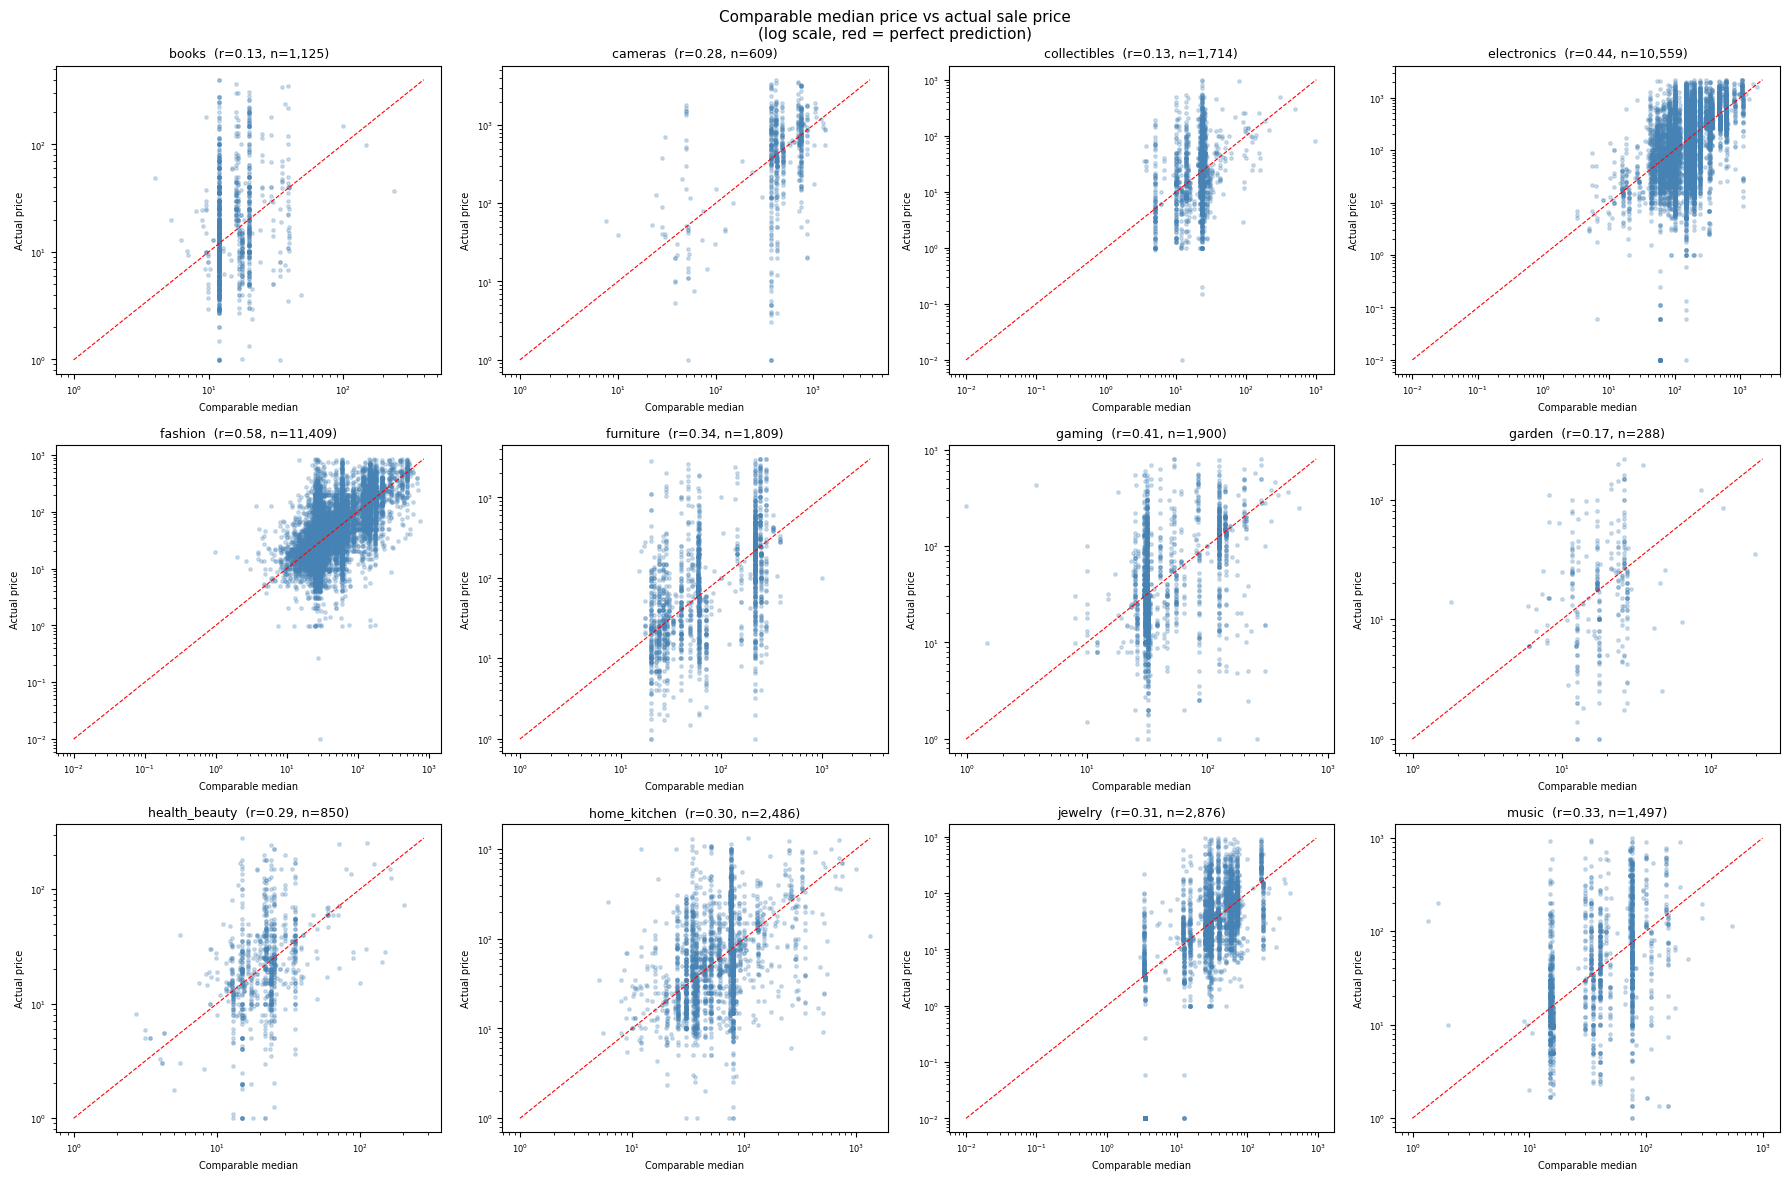

✓ Diagnostics complete


In [86]:
# ── Comparable stats quality diagnostics ─────────────────────────────────────
# Answers: "are the comparable stats actually comparable to each row?"
# Four checks:
#   1. Correlation between comparable_median and sale_price per category
#   2. Group size distribution (coverage)
#   3. Fallback rate (how often comparable_key had <2 neighbours)
#   4. Sample inspection — pick a random group from high-variance categories
#      and print every item in it so you can eyeball whether they're truly alike

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# ── 1. Correlation per category ───────────────────────────────────────────────
print("=" * 68)
print("  COMPARABLE MEDIAN  ↔  ACTUAL SALE PRICE  (Pearson r per category)")
print("=" * 68)
has_comp = clean[clean["comparable_count"] > 0].copy()
corr_rows = []
for cat, grp in has_comp.groupby("category"):
    if len(grp) < 10:
        continue
    r = grp[["comparable_median_price", "sale_price"]].corr().iloc[0, 1]
    corr_rows.append({"category": cat, "n": len(grp), "pearson_r": round(r, 3)})
corr_df = pd.DataFrame(corr_rows).sort_values("pearson_r", ascending=False)
print(corr_df.to_string(index=False))
print()

# ── 2. Group size distribution ────────────────────────────────────────────────
print("=" * 68)
print("  GROUP SIZE DISTRIBUTION  (comparable_count = LOO peers seen)")
print("=" * 68)
bins = [0, 1, 5, 10, 20, 50, np.inf]
labels = ["0 (fallback)", "1–4", "5–9", "10–19", "20–49", "50+"]
clean["_size_bin"] = pd.cut(clean["comparable_count"], bins=bins, labels=labels, right=False)
size_dist = (
    clean["_size_bin"].value_counts().reindex(labels).fillna(0).astype(int)
)
pct = (size_dist / len(clean) * 100).round(1)
for label, cnt, p in zip(labels, size_dist, pct):
    bar = "█" * int(p / 2)
    print(f"  {label:<14}  {cnt:>6,}  ({p:5.1f}%)  {bar}")
clean.drop(columns=["_size_bin"], inplace=True)
print()

# ── 3. Fallback rate ──────────────────────────────────────────────────────────
fallback_n    = (clean["comparable_count"] == 0).sum()
category_fb_n = clean["comparable_median_price"].isna().sum()  # pre-cat-median fill → already 0
total         = len(clean)
print("=" * 68)
print("  FALLBACK RATE")
print("=" * 68)
print(f"  Rows using fallback (cat|cond)  : {fallback_n:,}  ({fallback_n/total*100:.1f}%)")
print(f"  Rows with comparable peers ≥2   : {total-fallback_n:,}  ({(total-fallback_n)/total*100:.1f}%)")
print()

# ── 4. Sample group inspection ────────────────────────────────────────────────
print("=" * 68)
print("  SAMPLE GROUP INSPECTION  (are the items in each group alike?)")
print("=" * 68)

INSPECT_CATS = ["cameras", "electronics", "sports", "music", "jewelry"]
rng = np.random.default_rng(42)

for cat in INSPECT_CATS:
    # Pick the comparable_key with most members for a rich sample
    cat_keys = clean.loc[clean["category"] == cat, "comparable_key"].value_counts()
    if len(cat_keys) == 0:
        continue
    # Take a key with 4–15 members so it's readable
    candidates = cat_keys[(cat_keys >= 4) & (cat_keys <= 15)]
    if len(candidates) == 0:
        candidates = cat_keys.head(5)
    chosen_key = rng.choice(candidates.index)
    grp = clean.loc[clean["comparable_key"] == chosen_key,
                    ["title", "brand_clean", "condition_clean", "sale_price",
                     "comparable_median_price", "comparable_count"]].copy()
    print(f"\n  Category : {cat}")
    print(f"  Key      : {chosen_key}  ({len(grp)} items)")
    print(f"  Price range: ${grp['sale_price'].min():.2f} – ${grp['sale_price'].max():.2f}  "
          f"| median ${grp['sale_price'].median():.2f}")
    print()
    for _, row in grp.iterrows():
        title_short = str(row["title"])[:70].ljust(70)
        print(f"    ${row['sale_price']:>8.2f}  |  {title_short}")
    print()

# ── 5. Scatter: comparable_median vs sale_price (log scale) ──────────────────
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()
cats = sorted(clean["category"].unique())
for i, cat in enumerate(cats[:12]):
    ax = axes[i]
    sub = clean[(clean["category"] == cat) & (clean["comparable_count"] > 0)]
    if len(sub) < 5:
        ax.set_visible(False)
        continue
    ax.scatter(sub["comparable_median_price"], sub["sale_price"],
               alpha=0.25, s=6, color="steelblue")
    mn = min(sub["comparable_median_price"].min(), sub["sale_price"].min())
    mx = max(sub["comparable_median_price"].max(), sub["sale_price"].max())
    ax.plot([mn, mx], [mn, mx], "r--", linewidth=0.8, label="ideal")
    ax.set_xscale("log"); ax.set_yscale("log")
    r = sub[["comparable_median_price","sale_price"]].corr().iloc[0,1]
    ax.set_title(f"{cat}  (r={r:.2f}, n={len(sub):,})", fontsize=9)
    ax.set_xlabel("Comparable median", fontsize=7)
    ax.set_ylabel("Actual price", fontsize=7)
    ax.tick_params(labelsize=6)
for j in range(len(cats), 12):
    axes[j].set_visible(False)
plt.suptitle("Comparable median price vs actual sale price\n(log scale, red = perfect prediction)",
             fontsize=11)
plt.tight_layout()
plt.show()
print("✓ Diagnostics complete")


## 2. Condition ordinal encoding

Map the 5 extracted condition labels to an ordered integer so XGBoost can
exploit the natural ordering: new > open_box > refurbished > used > for_parts.

| condition | ordinal |
|---|---|
| new | 4 |
| open_box | 3 |
| refurbished | 2 |
| used | 1 |
| for_parts | 0 |
| unknown / NaN | −1 (sentinel) |

In [87]:
CONDITION_ORDINAL = {
    "new":         4,
    "open_box":    3,
    "refurbished": 2,
    "used":        1,
    "for_parts":   0,
}

clean["condition_ord"] = (
    clean["condition_clean"]
    .map(CONDITION_ORDINAL)
    .fillna(-1)
    .astype(int)
)

print("Condition ordinal distribution:")
print(clean[["condition_clean", "condition_ord"]].value_counts().sort_index())
print(f"\nUnknown / NaN condition (−1): {(clean['condition_ord'] == -1).sum():,} rows")

Condition ordinal distribution:
condition_clean                           condition_ord
acceptable                                -1                104
brand new                                 -1                251
certified - refurbished                   -1                  9
detailsouter⇒dyed・stain. shoulder height  -1                  1
excellent - refurbished                   -1                 33
for_parts                                  0                459
good                                      -1                332
good - refurbished                        -1                 40
graded - cgc 10                           -1                  3
graded - cgc 9                            -1                  1
graded - other 7                          -1                  1
graded - psa 10                           -1                  6
graded - psa 4                            -1                  1
graded - psa 5                            -1                  1
graded - psa 8  

## 3. Title embeddings → PCA

Encode each title with `all-MiniLM-L6-v2` (384-dim), fit PCA on the full
384 components, then pick `n_components` at the elbow of the cumulative
explained-variance curve rather than fixing it up front.

Encoding 41,454 titles...


Batches: 100%|██████████| 648/648 [00:42<00:00, 15.14it/s]


Components to reach 80.0% variance: 65  →  capped at 32
Cumulative variance at 32 components: 49.8%


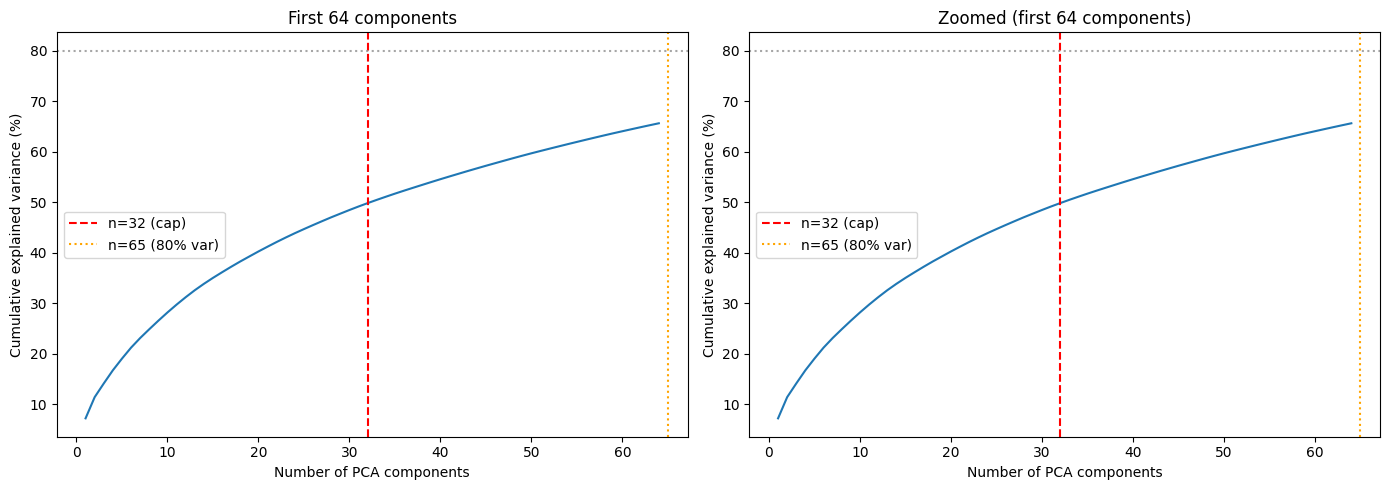

Added 32 PCA columns: ['title_pc1', 'title_pc2', 'title_pc3', 'title_pc4', 'title_pc5'] ...
clean.shape: (41454, 60)


In [88]:
from sklearn.decomposition import PCA
import gc

# ── Step 1: encode titles ─────────────────────────────────────────────
titles_list = clean["title"].fillna("").astype(builtins.str).tolist()
print(f"Encoding {len(titles_list):,} titles...")

title_embeds = model.encode(
    titles_list,
    convert_to_tensor=False,
    normalize_embeddings=True,
    batch_size=64,
    show_progress_bar=True,
)  # (n_rows, 384)

# ── Step 2: exploratory PCA capped at 64 components ──────────────────
# Full 384-component SVD on a [42k×384] matrix requires ~700 MB of scratch
# space. Capping at 64 uses randomised SVD instead, which is far cheaper
# and still covers our 32-component hard cap comfortably.
N_EXPLORE = 64
pca_full = PCA(n_components=N_EXPLORE, random_state=42)
pca_full.fit(title_embeds)

cum_var = np.cumsum(pca_full.explained_variance_ratio_) * 100
n_components_range = np.arange(1, len(cum_var) + 1)

# ── Step 3: pick n — 80% variance target, hard-capped at 32 ──────────
# MiniLM spreads variance across many dims (diverse product categories),
# so the 80% target lands at ~85. Cap at 32 to avoid overfitting on 8k rows.
N_CAP = 32
TARGET_VAR = 80.0
elbow_uncapped = int(np.searchsorted(cum_var, TARGET_VAR)) + 1
elbow = min(elbow_uncapped, N_CAP)
print(f"Components to reach {TARGET_VAR}% variance: {elbow_uncapped}  →  capped at {elbow}")
print(f"Cumulative variance at {elbow} components: {cum_var[elbow-1]:.1f}%")

# ── Step 4: cumulative variance plot ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(n_components_range, cum_var, linewidth=1.5)
axes[0].axvline(elbow, color="red", linestyle="--", label=f"n={elbow} (cap)")
axes[0].axvline(elbow_uncapped, color="orange", linestyle=":", label=f"n={elbow_uncapped} (80% var)")
axes[0].axhline(TARGET_VAR, color="grey", linestyle=":", alpha=0.7)
axes[0].set_xlabel("Number of PCA components")
axes[0].set_ylabel("Cumulative explained variance (%)")
axes[0].set_title(f"First {N_EXPLORE} components")
axes[0].legend()

zoom = min(elbow_uncapped * 2, N_EXPLORE)
axes[1].plot(n_components_range[:zoom], cum_var[:zoom], linewidth=1.5)
axes[1].axvline(elbow, color="red", linestyle="--", label=f"n={elbow} (cap)")
axes[1].axvline(elbow_uncapped, color="orange", linestyle=":", label=f"n={elbow_uncapped} (80% var)")
axes[1].axhline(TARGET_VAR, color="grey", linestyle=":", alpha=0.7)
axes[1].set_xlabel("Number of PCA components")
axes[1].set_ylabel("Cumulative explained variance (%)")
axes[1].set_title(f"Zoomed (first {zoom} components)")
axes[1].legend()

plt.tight_layout()
plt.show()

# ── Step 5: refit PCA with chosen n and add columns to clean ──────────
del pca_full  # free exploratory model before refitting
pca = PCA(n_components=elbow, random_state=42)
pca_features = pca.fit_transform(title_embeds)

del title_embeds  # large array no longer needed
gc.collect()

pc_cols = [f"title_pc{i}" for i in range(1, elbow + 1)]
clean   = clean.drop(columns=[c for c in clean.columns if c.startswith("title_pc")], errors="ignore")
clean   = pd.concat([clean, pd.DataFrame(pca_features, columns=pc_cols, index=clean.index)], axis=1)

print(f"Added {elbow} PCA columns: {pc_cols[:5]} ...")
print(f"clean.shape: {clean.shape}")


## 4. Description embeddings → PCA

Same approach as title embeddings but on the listing description.
Descriptions are longer and noisier, so we truncate to the first 150 words
(MiniLM has a 256-token limit) and expect the useful variance to concentrate
in fewer components than titles. Same 32-component cap applies.

Encoding 41,454 descriptions...


Batches: 100%|██████████| 648/648 [01:41<00:00,  6.40it/s]


Components to reach 80.0% variance: 65  →  capped at 32
Cumulative variance at 32 components: 48.5%


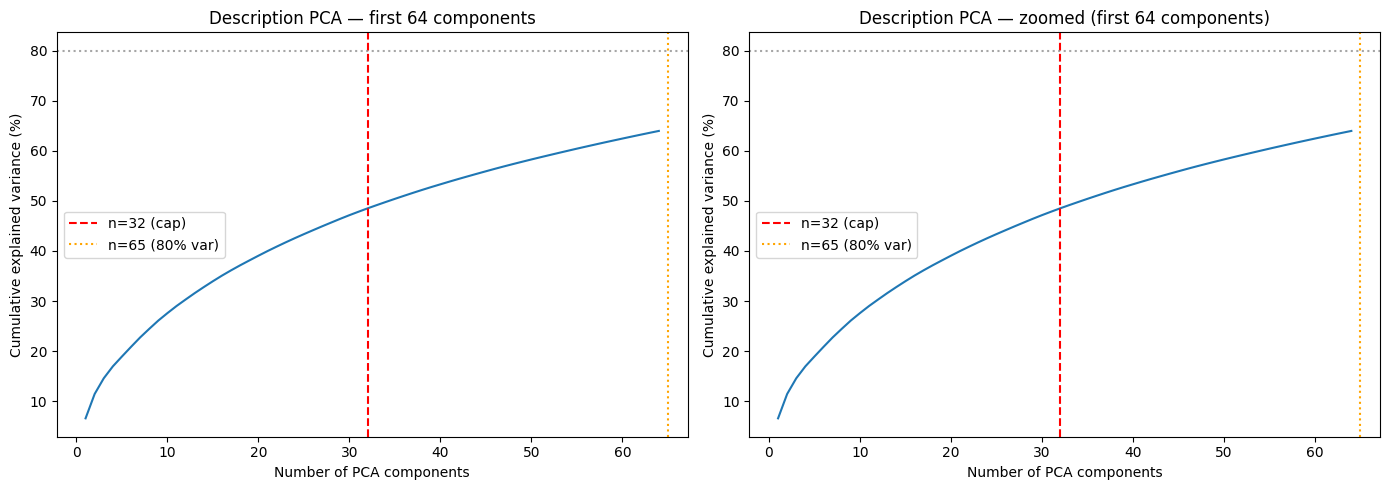

Added 32 description PCA columns: ['desc_pc1', 'desc_pc2', 'desc_pc3', 'desc_pc4', 'desc_pc5'] ...
clean.shape: (41454, 92)


In [89]:
import gc

# ── Step 1: encode descriptions (truncated to first 150 words) ───────
desc_list = (
    clean["description"]
    .fillna("")
    .astype(builtins.str)
    .str.split()
    .str[:150]
    .str.join(" ")
    .tolist()
)
print(f"Encoding {len(desc_list):,} descriptions...")

desc_embeds = model.encode(
    desc_list,
    convert_to_tensor=False,
    normalize_embeddings=True,
    batch_size=64,
    show_progress_bar=True,
)  # (n_rows, 384)

# ── Step 2: exploratory PCA capped at 64 components ──────────────────
N_EXPLORE_DESC = 64
pca_desc_full = PCA(n_components=N_EXPLORE_DESC, random_state=42)
pca_desc_full.fit(desc_embeds)

cum_var_desc = np.cumsum(pca_desc_full.explained_variance_ratio_) * 100
n_range_desc = np.arange(1, len(cum_var_desc) + 1)

# ── Step 3: 80% variance target, hard-capped at 32 ───────────────────
N_CAP_DESC = 32
TARGET_VAR_DESC = 80.0
elbow_desc_uncapped = int(np.searchsorted(cum_var_desc, TARGET_VAR_DESC)) + 1
elbow_desc = min(elbow_desc_uncapped, N_CAP_DESC)
print(f"Components to reach {TARGET_VAR_DESC}% variance: {elbow_desc_uncapped}  →  capped at {elbow_desc}")
print(f"Cumulative variance at {elbow_desc} components: {cum_var_desc[elbow_desc-1]:.1f}%")

# ── Step 4: cumulative variance plot ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(n_range_desc, cum_var_desc, linewidth=1.5)
axes[0].axvline(elbow_desc, color="red", linestyle="--", label=f"n={elbow_desc} (cap)")
axes[0].axvline(elbow_desc_uncapped, color="orange", linestyle=":", label=f"n={elbow_desc_uncapped} (80% var)")
axes[0].axhline(TARGET_VAR_DESC, color="grey", linestyle=":", alpha=0.7)
axes[0].set_xlabel("Number of PCA components")
axes[0].set_ylabel("Cumulative explained variance (%)")
axes[0].set_title(f"Description PCA — first {N_EXPLORE_DESC} components")
axes[0].legend()

zoom_desc = min(elbow_desc_uncapped * 2, N_EXPLORE_DESC)
axes[1].plot(n_range_desc[:zoom_desc], cum_var_desc[:zoom_desc], linewidth=1.5)
axes[1].axvline(elbow_desc, color="red", linestyle="--", label=f"n={elbow_desc} (cap)")
axes[1].axvline(elbow_desc_uncapped, color="orange", linestyle=":", label=f"n={elbow_desc_uncapped} (80% var)")
axes[1].axhline(TARGET_VAR_DESC, color="grey", linestyle=":", alpha=0.7)
axes[1].set_xlabel("Number of PCA components")
axes[1].set_ylabel("Cumulative explained variance (%)")
axes[1].set_title(f"Description PCA — zoomed (first {zoom_desc} components)")
axes[1].legend()

plt.tight_layout()
plt.show()

# ── Step 5: refit and add columns ─────────────────────────────────────
del pca_desc_full  # free exploratory model before refitting
pca_desc = PCA(n_components=elbow_desc, random_state=42)
desc_pca_features = pca_desc.fit_transform(desc_embeds)

del desc_embeds  # large array no longer needed
gc.collect()

desc_pc_cols = [f"desc_pc{i}" for i in range(1, elbow_desc + 1)]
clean = clean.drop(columns=[c for c in clean.columns if c.startswith("desc_pc")], errors="ignore")
clean = pd.concat(
    [clean, pd.DataFrame(desc_pca_features, columns=desc_pc_cols, index=clean.index)],
    axis=1,
)

print(f"Added {elbow_desc} description PCA columns: {desc_pc_cols[:5]} ...")
print(f"clean.shape: {clean.shape}")


## 5. Title length

Word count of the listing title — a cheap proxy for listing effort.
Sellers who write more descriptive titles tend to price higher-value items.

Title length stats:
count    41454.0
mean        11.2
std          2.8
min          1.0
25%         10.0
50%         12.0
75%         13.0
max         37.0
Name: title_length, dtype: float64


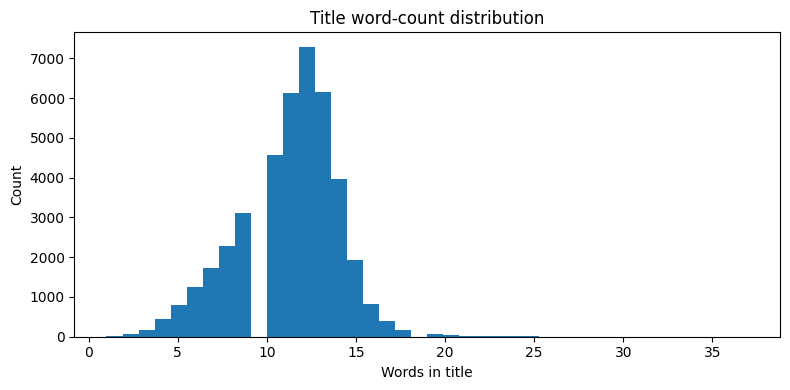

In [90]:
clean["title_length"] = clean["title"].str.split().str.len().fillna(0).astype(int)

print("Title length stats:")
print(clean["title_length"].describe().round(1))

plt.figure(figsize=(8, 4))
plt.hist(clean["title_length"], bins=40, edgecolor="none")
plt.title("Title word-count distribution")
plt.xlabel("Words in title")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

## 6. Target encoding — brand and category

`brand_clean` has high cardinality (100+ unique values) and `category` has 8.
One-hot encoding brand would balloon the feature matrix; target encoding replaces
each label with its mean log-price.

To prevent leakage, encoding is done **out-of-fold (OOF)**: the dataset is split
into 5 folds; each fold's encoded values are computed from the other 4 folds only.
A global smoothed mean is used for unseen labels at inference time.

In [91]:
from sklearn.model_selection import KFold

def target_encode_oof(df, col, target_col="log_price", n_splits=5, smoothing=10):
    """Out-of-fold target encoding with smoothing toward the global mean."""
    encoded = pd.Series(np.nan, index=df.index)
    global_mean = df[target_col].mean()
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

    for train_idx, val_idx in kf.split(df):
        train_fold = df.iloc[train_idx]
        val_fold   = df.iloc[val_idx]

        # Per-label stats on training fold
        stats = train_fold.groupby(col)[target_col].agg(["mean", "count"])
        # Smoothed mean: blend label mean toward global mean based on count
        stats["smoothed"] = (
            (stats["count"] * stats["mean"] + smoothing * global_mean)
            / (stats["count"] + smoothing)
        )
        encoded.iloc[val_idx] = val_fold[col].map(stats["smoothed"]).fillna(global_mean).values

    return encoded


clean["log_price"] = np.log1p(clean["sale_price"])

clean["brand_enc"]    = target_encode_oof(clean, "brand_clean")
clean["category_enc"] = target_encode_oof(clean, "category")

print("Brand target encoding sample:")
print(
    clean.groupby("brand_clean")[["brand_enc", "log_price"]]
    .mean().round(3)
    .sort_values("brand_enc", ascending=False)
    .head(15)
)
print("\nCategory target encoding:")
print(clean.groupby("category")[["category_enc", "log_price"]].mean().round(3))

Brand target encoding sample:
                  brand_enc  log_price
brand_clean                           
fujifilm              6.261      6.637
canon                 6.181      6.459
custom, whitebox      6.148      6.201
nikon                 6.016      6.470
asus                  5.767      5.881
trek                  5.766      6.314
louis vuitton         5.723      5.961
sony                  5.717      5.745
msi                   5.616      5.841
panasonic             5.614      5.850
lenovo                5.572      5.627
herman miller         5.543      5.995
alienware             5.536      6.044
specialized           5.514      5.936
microsoft             5.483      5.522

Category target encoding:
               category_enc  log_price
category                              
books                 2.902      2.888
cameras               5.868      5.905
collectibles          3.128      3.121
electronics           4.896      4.897
fashion               3.816      3.816
furnitu

## 7. Temporal features

Parse `listing_date_text` to extract day-of-week and month, then encode
as **sin/cos pairs** so the model sees the cyclical nature of time
(e.g. Sunday is adjacent to Saturday, not distant from it).

Rows where the date cannot be parsed get sin=0, cos=1 (angle=0 sentinel).

In [92]:
import re
from datetime import datetime

# eBay date text examples:
#   "This listing sold on Tue, Apr 28 at 1:34 AM."
#   "This Buy It Now listing sold on Tue, Apr 28 at ..."
DATE_RE = re.compile(
    r'(?:Mon|Tue|Wed|Thu|Fri|Sat|Sun),\s*'
    r'(Jan|Feb|Mar|Apr|May|Jun|Jul|Aug|Sep|Oct|Nov|Dec)\s+(\d{1,2})',
    re.IGNORECASE,
)
CURRENT_YEAR = 2026

def parse_listing_date(text):
    if pd.isna(text):
        return None
    m = DATE_RE.search(builtins.str(text))
    if not m:
        return None
    try:
        return datetime.strptime(f"{m.group(1)} {m.group(2)} {CURRENT_YEAR}", "%b %d %Y")
    except ValueError:
        return None

clean["listing_date"] = clean["listing_date_text"].apply(parse_listing_date)

parsed_pct = clean["listing_date"].notna().mean()
print(f"Date parse rate: {parsed_pct:.1%}")

# Day-of-week: 0=Monday … 6=Sunday
dow = clean["listing_date"].dt.dayofweek.fillna(0).astype(int)
clean["dow_sin"] = np.sin(2 * np.pi * dow / 7)
clean["dow_cos"] = np.cos(2 * np.pi * dow / 7)

# Month: 1=Jan … 12=Dec
month = clean["listing_date"].dt.month.fillna(1).astype(int)
clean["month_sin"] = np.sin(2 * np.pi * (month - 1) / 12)
clean["month_cos"] = np.cos(2 * np.pi * (month - 1) / 12)

print("\nDay-of-week distribution (0=Mon, 6=Sun):")
print(dow.value_counts().sort_index())
print("\nMonth distribution:")
print(month.value_counts().sort_index())

Date parse rate: 82.6%

Day-of-week distribution (0=Mon, 6=Sun):
listing_date
0    13069
1     7121
2    12798
3     2112
4     2835
5     1431
6     2088
Name: count, dtype: int64

Month distribution:
listing_date
1     7207
2      225
3      820
4    26934
5     6175
6       92
7        1
Name: count, dtype: int64


## 8. Assemble final feature matrix

Collect all engineered columns, drop rows still missing critical features,
and save the final dataset to parquet ready for model training.

In [93]:
pc_title_cols = [c for c in clean.columns if c.startswith("title_pc")]
pc_desc_cols  = [c for c in clean.columns if c.startswith("desc_pc")]

FEATURE_COLS = [
    # Numeric
    "description_length",
    "image_count",
    "title_length",
    # Condition
    "condition_ord",
    # Comparable stats
    "comparable_median_price",
    "comparable_mean_price",
    "comparable_stdev_price",
    "comparable_count",
    # Target-encoded categoricals
    "brand_enc",
    "category_enc",
    # Temporal
    "dow_sin", "dow_cos",
    "month_sin", "month_cos",
] + pc_title_cols + pc_desc_cols

TARGET_COL = "log_price"

# Deduplicate columns in case any PCA cell was re-run multiple times
clean = clean.loc[:, ~clean.columns.duplicated()]

model_df = clean[FEATURE_COLS + [TARGET_COL, "sale_price", "category", "listing_url"]].copy()

# Drop rows with any NaN in feature columns
before = len(model_df)
model_df = model_df.dropna(subset=FEATURE_COLS + [TARGET_COL])
print(f"Dropped {before - len(model_df):,} rows with missing features → {len(model_df):,} rows remaining")

print(f"\nFeature matrix: {len(FEATURE_COLS)} features × {len(model_df):,} rows")
print(f"  Numeric/condition/comparable: 8")
print(f"  Target-encoded categoricals:  2")
print(f"  Temporal sin/cos:             4")
print(f"  Title PCA components:         {len(pc_title_cols)}")
print(f"  Description PCA components:   {len(pc_desc_cols)}")

model_df.to_parquet("output/model_ready.parquet", index=False)
print(f"\nSaved → output/model_ready.parquet")

print("\nTarget (log_price) stats:")
print(model_df[TARGET_COL].describe().round(3))

Dropped 0 rows with missing features → 41,454 rows remaining

Feature matrix: 78 features × 41,454 rows
  Numeric/condition/comparable: 8
  Target-encoded categoricals:  2
  Temporal sin/cos:             4
  Title PCA components:         32
  Description PCA components:   32

Saved → output/model_ready.parquet

Target (log_price) stats:
count    41454.000
mean         4.106
std          1.363
min          0.010
25%          3.102
50%          3.973
75%          5.087
max          8.243
Name: log_price, dtype: float64


# Model Training

## Baseline — Random Forest

Random Forest is used as the baseline: no boosting, high variance, resistant
to overfitting by construction. If XGBoost and LightGBM cannot beat this,
something is wrong with the feature engineering.

Target: `log(price + 1)`. Predictions are exponentiated back to USD for
interpretability.

Category counts after singleton drop:
category
fashion          11414
electronics      10571
sports            3068
jewelry           2889
home_kitchen      2496
gaming            1907
furniture         1818
collectibles      1726
music             1502
tools             1168
books             1133
health_beauty      855
cameras            614
garden             293
Name: count, dtype: int64
Train: 33,163  |  Val: 8,291  |  Features: 78

── Random Forest baseline ─────────────────────────────
  RMSE (log scale): 0.6608
  RMSE (USD):       $193.09
  MAE  (USD):       $62.91
  MAPE:             66.4%
  R²   (log scale): 0.7616
  Within 20%:       41.1% of predictions

Per-category breakdown:
                    n  RMSE_USD  MAE_USD  MAPE_%  Within20%
category                                                   
cameras         123.0    703.77   350.16   63.35      28.46
furniture       364.0    354.19   106.65   65.62      44.23
sports          614.0    350.59   125.67   79.73      33.71
e

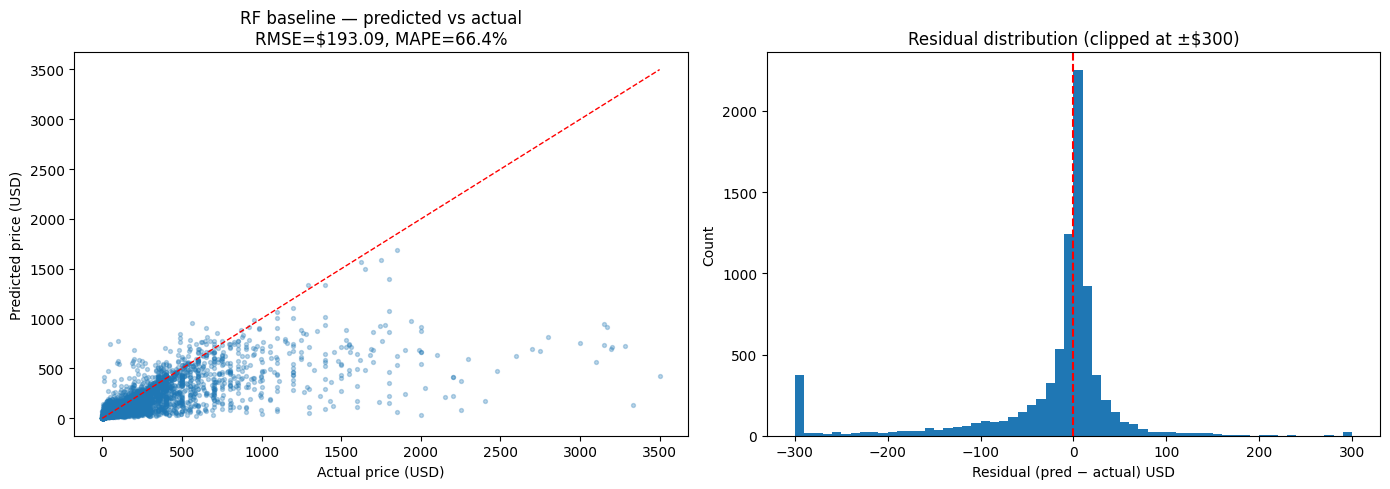

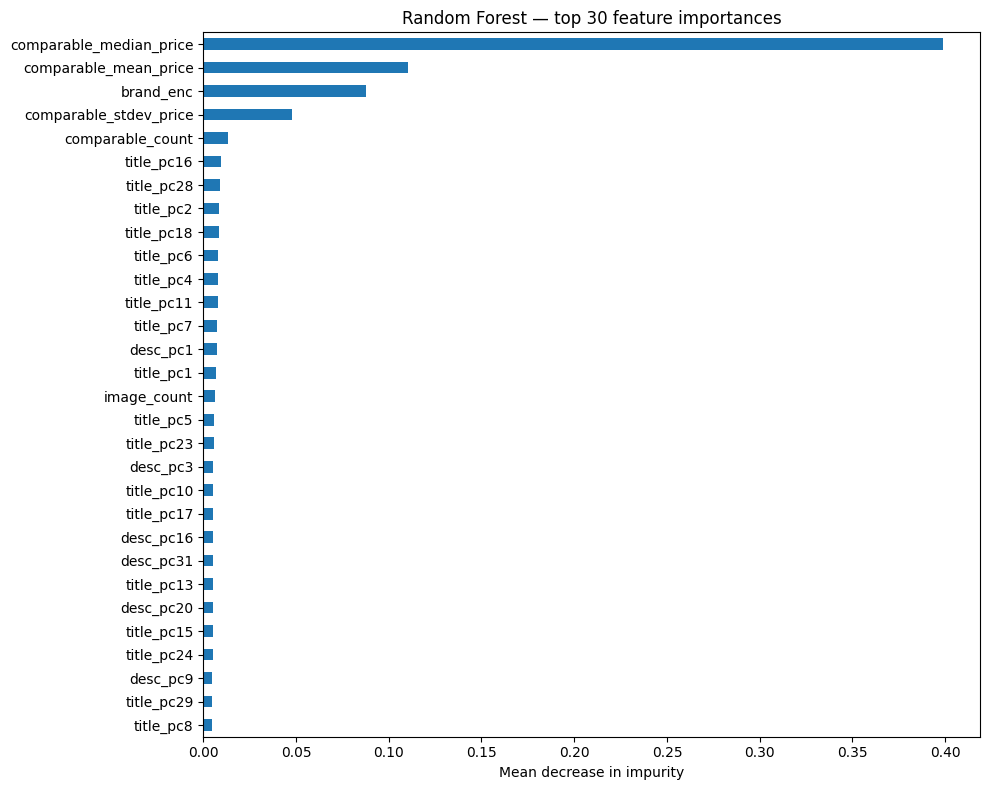

In [94]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

model_df = pd.read_parquet("output/model_ready.parquet")

FEATURE_COLS = [c for c in model_df.columns
                if c not in ("log_price", "sale_price", "category", "listing_url")]
TARGET_COL   = "log_price"

# Drop categories with fewer than 2 rows — cannot stratify on singletons
cat_counts = model_df["category"].value_counts()
model_df = model_df[model_df["category"].isin(cat_counts[cat_counts >= 2].index)].copy()
print(f"Category counts after singleton drop:")
print(model_df["category"].value_counts())

X = model_df[FEATURE_COLS].values
y = model_df[TARGET_COL].values

# Stratify on category so every category is proportionally represented
# in both train and val — critical for small categories (luxury, collectibles)
X_train, X_val, y_train, y_val, idx_train, idx_val = train_test_split(
    X, y, np.arange(len(model_df)),
    test_size=0.2,
    random_state=42,
    stratify=model_df["category"].values,
)
print(f"Train: {len(X_train):,}  |  Val: {len(X_val):,}  |  Features: {X_train.shape[1]}")

# ── Train ─────────────────────────────────────────────────────────────
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=3,
    n_jobs=-1,
    random_state=42,
)
rf.fit(X_train, y_train)

# ── Predictions ───────────────────────────────────────────────────────
y_pred_log = rf.predict(X_val)
y_pred_usd = np.expm1(y_pred_log)
y_true_usd = np.expm1(y_val)

# ── Overall metrics ───────────────────────────────────────────────────
rmse_log = np.sqrt(mean_squared_error(y_val, y_pred_log))
rmse_usd = np.sqrt(mean_squared_error(y_true_usd, y_pred_usd))
mae_usd  = mean_absolute_error(y_true_usd, y_pred_usd)
r2       = r2_score(y_val, y_pred_log)
mape      = np.mean(np.abs((y_true_usd - y_pred_usd) / (y_true_usd + 1e-9))) * 100
within_20 = np.mean(np.abs((y_true_usd - y_pred_usd) / (y_true_usd + 1e-9)) <= 0.20) * 100

print("\n── Random Forest baseline ─────────────────────────────")
print(f"  RMSE (log scale): {rmse_log:.4f}")
print(f"  RMSE (USD):       ${rmse_usd:.2f}")
print(f"  MAE  (USD):       ${mae_usd:.2f}")
print(f"  MAPE:             {mape:.1f}%")
print(f"  R²   (log scale): {r2:.4f}")
print(f"  Within 20%:       {within_20:.1f}% of predictions")

# ── Per-category RMSE breakdown ───────────────────────────────────────
val_df = model_df.iloc[idx_val][["category", "sale_price"]].copy()
val_df["pred_usd"] = y_pred_usd
val_df["true_usd"] = y_true_usd

cat_metrics = (
    val_df.groupby("category")
    .apply(lambda g: pd.Series({
        "n":        len(g),
        "RMSE_USD": np.sqrt(mean_squared_error(g["true_usd"], g["pred_usd"])),
        "MAE_USD":  mean_absolute_error(g["true_usd"], g["pred_usd"]),
        "MAPE_%":     np.mean(np.abs((g["true_usd"] - g["pred_usd"]) / (g["true_usd"] + 1e-9))) * 100,
        "Within20%":  np.mean(np.abs((g["true_usd"] - g["pred_usd"]) / (g["true_usd"] + 1e-9)) <= 0.20) * 100,
    }), include_groups=False)
    .sort_values("RMSE_USD", ascending=False)
    .round(2)
)
print("\nPer-category breakdown:")
print(cat_metrics.to_string())

# ── Predicted vs actual plot ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_true_usd, y_pred_usd, alpha=0.3, s=8)
lim = max(y_true_usd.max(), y_pred_usd.max())
axes[0].plot([0, lim], [0, lim], "r--", linewidth=1)
axes[0].set_xlabel("Actual price (USD)")
axes[0].set_ylabel("Predicted price (USD)")
axes[0].set_title(f"RF baseline — predicted vs actual\nRMSE=${rmse_usd:.2f}, MAPE={mape:.1f}%")

residuals = y_pred_usd - y_true_usd
axes[1].hist(residuals.clip(-300, 300), bins=60, edgecolor="none")
axes[1].axvline(0, color="red", linestyle="--")
axes[1].set_xlabel("Residual (pred − actual) USD")
axes[1].set_ylabel("Count")
axes[1].set_title("Residual distribution (clipped at ±$300)")

plt.tight_layout()
plt.show()

# ── Feature importance (top 30) ───────────────────────────────────────
importances = pd.Series(rf.feature_importances_, index=FEATURE_COLS)
top30 = importances.sort_values(ascending=False).head(30)

plt.figure(figsize=(10, 8))
top30.sort_values().plot(kind="barh")
plt.title("Random Forest — top 30 feature importances")
plt.xlabel("Mean decrease in impurity")
plt.tight_layout()
plt.show()

## XGBoost

Level-wise gradient boosting with L1/L2 regularisation.
Same train/val split and metrics as the RF baseline for a direct comparison.

[0]	validation_0-rmse:1.32172
[100]	validation_0-rmse:0.82856
[200]	validation_0-rmse:0.78765
[300]	validation_0-rmse:0.76196
[400]	validation_0-rmse:0.73983
[500]	validation_0-rmse:0.72153
[600]	validation_0-rmse:0.70943
[700]	validation_0-rmse:0.70095
[800]	validation_0-rmse:0.69437
[900]	validation_0-rmse:0.68785
[1000]	validation_0-rmse:0.68080
[1100]	validation_0-rmse:0.67670
[1200]	validation_0-rmse:0.67283
[1300]	validation_0-rmse:0.66945
[1400]	validation_0-rmse:0.66755
[1500]	validation_0-rmse:0.66502
[1600]	validation_0-rmse:0.66306
[1700]	validation_0-rmse:0.66073
[1800]	validation_0-rmse:0.65882
[1900]	validation_0-rmse:0.65786
[2000]	validation_0-rmse:0.65666
[2100]	validation_0-rmse:0.65560
[2200]	validation_0-rmse:0.65429
[2300]	validation_0-rmse:0.65348
[2400]	validation_0-rmse:0.65280
[2500]	validation_0-rmse:0.65183
[2600]	validation_0-rmse:0.65124
[2700]	validation_0-rmse:0.65087
[2800]	validation_0-rmse:0.65040
[2900]	validation_0-rmse:0.64986
[2999]	validation_0-rm

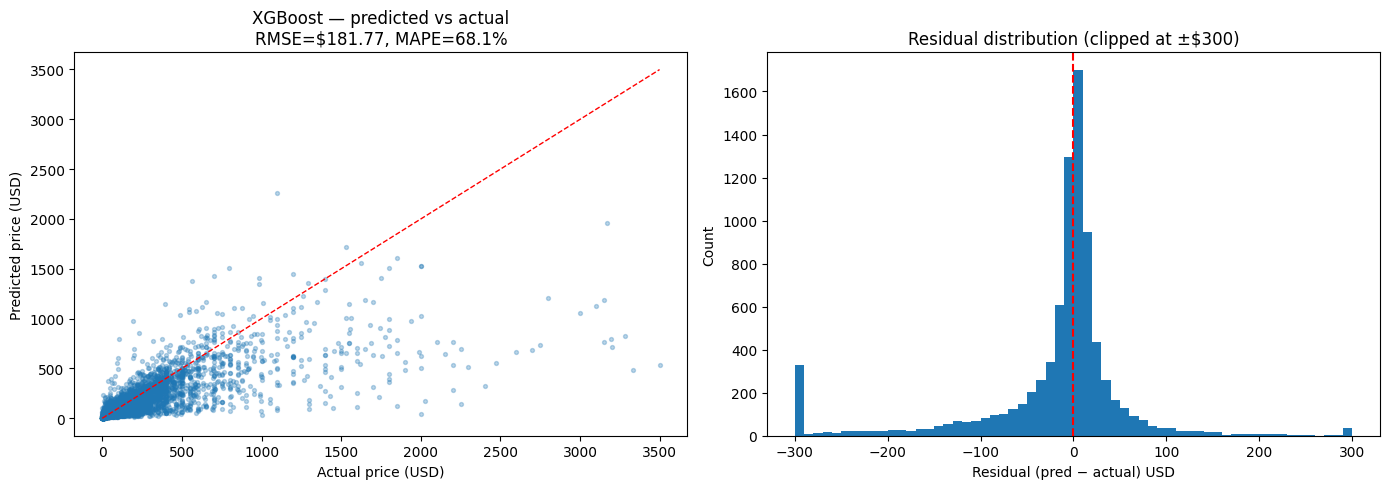

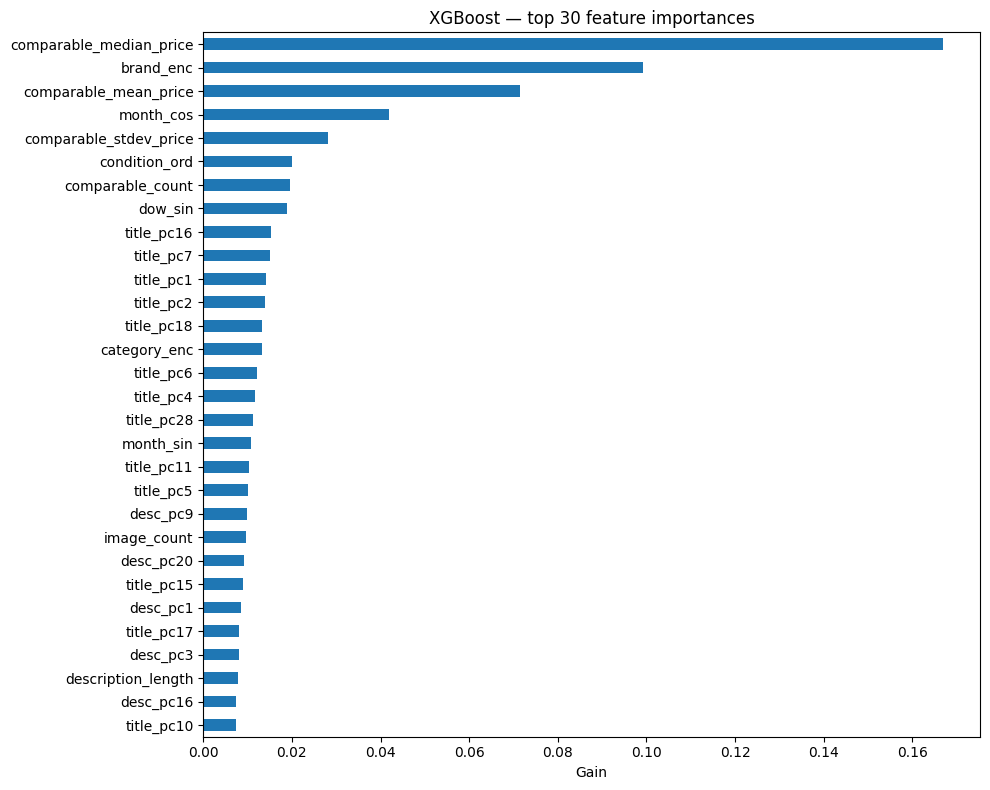

In [95]:
import gc
import xgboost as xgb

# Free large arrays left over from feature engineering before allocating XGBoost
for _var in ["title_embeds", "desc_embeds", "pca_features", "desc_pca_features"]:
    if _var in dir():
        del _var
gc.collect()

xgb_model = xgb.XGBRegressor(
    n_estimators=3000,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    reg_alpha=0.1,
    reg_lambda=1.0,
    early_stopping_rounds=50,
    eval_metric="rmse",
    tree_method="hist",
    device="cpu",
    n_jobs=-1,
    random_state=42,
)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=100,
)

# ── Predictions ───────────────────────────────────────────────────────
y_pred_log_xgb = xgb_model.predict(X_val)
y_pred_usd_xgb = np.expm1(y_pred_log_xgb)
y_true_usd_xgb = np.expm1(y_val)

# ── Overall metrics ───────────────────────────────────────────────────
rmse_log_xgb = np.sqrt(mean_squared_error(y_val, y_pred_log_xgb))
rmse_usd_xgb = np.sqrt(mean_squared_error(y_true_usd_xgb, y_pred_usd_xgb))
mae_usd_xgb  = mean_absolute_error(y_true_usd_xgb, y_pred_usd_xgb)
r2_xgb       = r2_score(y_val, y_pred_log_xgb)
mape_xgb     = np.mean(np.abs((y_true_usd_xgb - y_pred_usd_xgb) / (y_true_usd_xgb + 1e-9))) * 100
within20_xgb = np.mean(np.abs((y_true_usd_xgb - y_pred_usd_xgb) / (y_true_usd_xgb + 1e-9)) <= 0.20) * 100

print("\n── XGBoost ────────────────────────────────────────────")
print(f"  Best iteration:   {xgb_model.best_iteration}")
print(f"  RMSE (log scale): {rmse_log_xgb:.4f}")
print(f"  RMSE (USD):       ${rmse_usd_xgb:.2f}")
print(f"  MAE  (USD):       ${mae_usd_xgb:.2f}")
print(f"  MAPE:             {mape_xgb:.1f}%")
print(f"  R²   (log scale): {r2_xgb:.4f}")
print(f"  Within 20%:       {within20_xgb:.1f}% of predictions")

# ── RF vs XGBoost comparison table ────────────────────────────────────
headers = f"  {"Metric":<20} {"RF":>10} {"XGBoost":>10} {"Delta":>10}"
print("\n── RF vs XGBoost ──────────────────────────────────────")
print(headers)
print(f"  {"-"*52}")
comparisons = [
    ("RMSE log",   rmse_log,  rmse_log_xgb),
    ("RMSE USD",   rmse_usd,  rmse_usd_xgb),
    ("MAE USD",    mae_usd,   mae_usd_xgb),
    ("MAPE %",     mape,      mape_xgb),
    ("R2",         r2,        r2_xgb),
    ("Within 20%", within_20, within20_xgb),
]
for label, rf_val, xgb_val in comparisons:
    delta = xgb_val - rf_val
    sign  = "+" if delta > 0 else ""
    print(f"  {label:<20} {rf_val:>10.3f} {xgb_val:>10.3f} {sign}{delta:>9.3f}")

# ── Per-category breakdown ─────────────────────────────────────────────
val_df_xgb = model_df.iloc[idx_val][["category", "sale_price"]].copy()
val_df_xgb["pred_usd"] = y_pred_usd_xgb
val_df_xgb["true_usd"] = y_true_usd_xgb

cat_metrics_xgb = (
    val_df_xgb.groupby("category")
    .apply(lambda g: pd.Series({
        "n":         len(g),
        "RMSE_USD":  np.sqrt(mean_squared_error(g["true_usd"], g["pred_usd"])),
        "MAE_USD":   mean_absolute_error(g["true_usd"], g["pred_usd"]),
        "MAPE_%":    np.mean(np.abs((g["true_usd"] - g["pred_usd"]) / (g["true_usd"] + 1e-9))) * 100,
        "Within20%": np.mean(np.abs((g["true_usd"] - g["pred_usd"]) / (g["true_usd"] + 1e-9)) <= 0.20) * 100,
    }), include_groups=False)
    .sort_values("RMSE_USD", ascending=False)
    .round(2)
)
print("\nPer-category breakdown:")
print(cat_metrics_xgb.to_string())

# ── Predicted vs actual + residuals ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_true_usd_xgb, y_pred_usd_xgb, alpha=0.3, s=8)
lim = max(y_true_usd_xgb.max(), y_pred_usd_xgb.max())
axes[0].plot([0, lim], [0, lim], "r--", linewidth=1)
axes[0].set_xlabel("Actual price (USD)")
axes[0].set_ylabel("Predicted price (USD)")
axes[0].set_title(f"XGBoost — predicted vs actual\nRMSE=${rmse_usd_xgb:.2f}, MAPE={mape_xgb:.1f}%")

residuals_xgb = y_pred_usd_xgb - y_true_usd_xgb
axes[1].hist(residuals_xgb.clip(-300, 300), bins=60, edgecolor="none")
axes[1].axvline(0, color="red", linestyle="--")
axes[1].set_xlabel("Residual (pred − actual) USD")
axes[1].set_ylabel("Count")
axes[1].set_title("Residual distribution (clipped at ±$300)")

plt.tight_layout()
plt.show()

# ── Feature importance (top 30) ───────────────────────────────────────
importances_xgb = pd.Series(xgb_model.feature_importances_, index=FEATURE_COLS)
top30_xgb = importances_xgb.sort_values(ascending=False).head(30)

plt.figure(figsize=(10, 8))
top30_xgb.sort_values().plot(kind="barh")
plt.title("XGBoost — top 30 feature importances")
plt.xlabel("Gain")
plt.tight_layout()
plt.show()

## LightGBM

Leaf-wise gradient boosting. Typically faster than XGBoost on tabular data
and often wins on structured datasets with many features.

[100]	valid_0's l2: 0.677815
[200]	valid_0's l2: 0.624987
[300]	valid_0's l2: 0.584714
[400]	valid_0's l2: 0.549765
[500]	valid_0's l2: 0.519102
[600]	valid_0's l2: 0.502892
[700]	valid_0's l2: 0.483032
[800]	valid_0's l2: 0.471648
[900]	valid_0's l2: 0.457016
[1000]	valid_0's l2: 0.449886
[1100]	valid_0's l2: 0.443441
[1200]	valid_0's l2: 0.436315
[1300]	valid_0's l2: 0.431061
[1400]	valid_0's l2: 0.427258
[1500]	valid_0's l2: 0.421539
[1600]	valid_0's l2: 0.41761
[1700]	valid_0's l2: 0.413818
[1800]	valid_0's l2: 0.411042
[1900]	valid_0's l2: 0.408547
[2000]	valid_0's l2: 0.406474
[2100]	valid_0's l2: 0.404671
[2200]	valid_0's l2: 0.402996
[2300]	valid_0's l2: 0.401524
[2400]	valid_0's l2: 0.399798
[2500]	valid_0's l2: 0.398995
[2600]	valid_0's l2: 0.398154
[2700]	valid_0's l2: 0.396274
[2800]	valid_0's l2: 0.395513
[2900]	valid_0's l2: 0.394416
[3000]	valid_0's l2: 0.393597


/Users/kevin/Programming/multi-agentic-sales-representative-system/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(



── LightGBM ───────────────────────────────────────────
  Best iteration:   2984
  RMSE (log scale): 0.6273
  RMSE (USD):       $177.73
  MAE  (USD):       $60.79
  MAPE:             64.2%
  R²   (log scale): 0.7851
  Within 20%:       35.7% of predictions

── RF vs XGBoost vs LightGBM ──────────────────────────
  Metric                     RF    XGBoost   LightGBM
  ----------------------------------------------------
  RMSE log                0.661      0.650      0.627
  RMSE USD              193.085    181.769    177.731
  MAE USD                62.914     63.546     60.785
  MAPE %                 66.421     68.117     64.178
  R2                      0.762      0.770      0.785
  Within 20%             41.069     33.325     35.701

Per-category breakdown:
                    n  RMSE_USD  MAE_USD  MAPE_%  Within20%
category                                                   
cameras         123.0    649.05   331.50   61.11      30.89
furniture       364.0    336.37   112.70   80.8

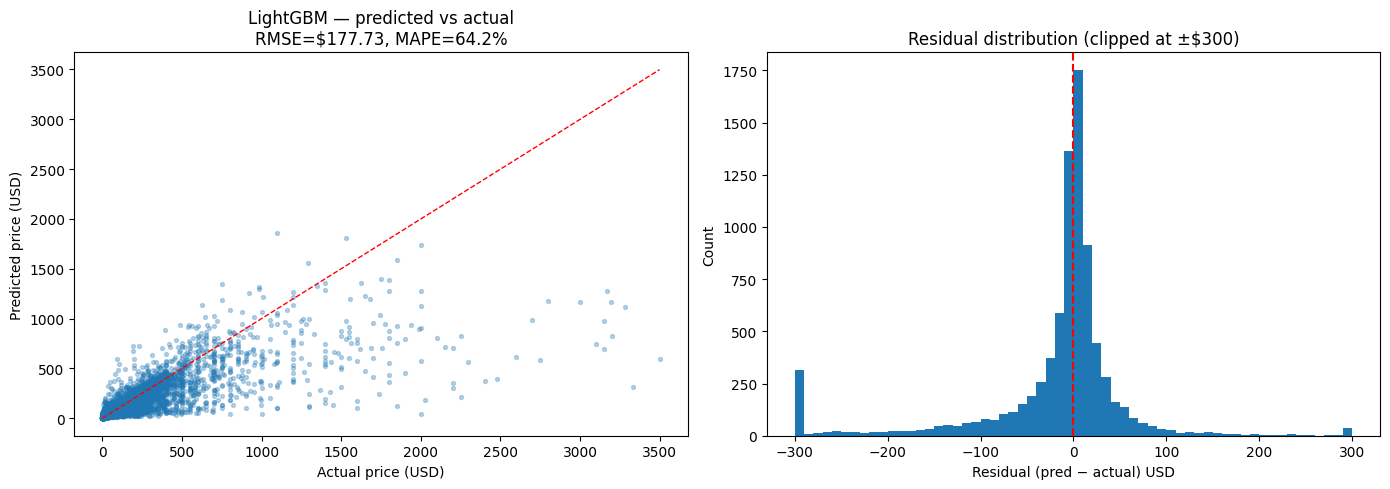

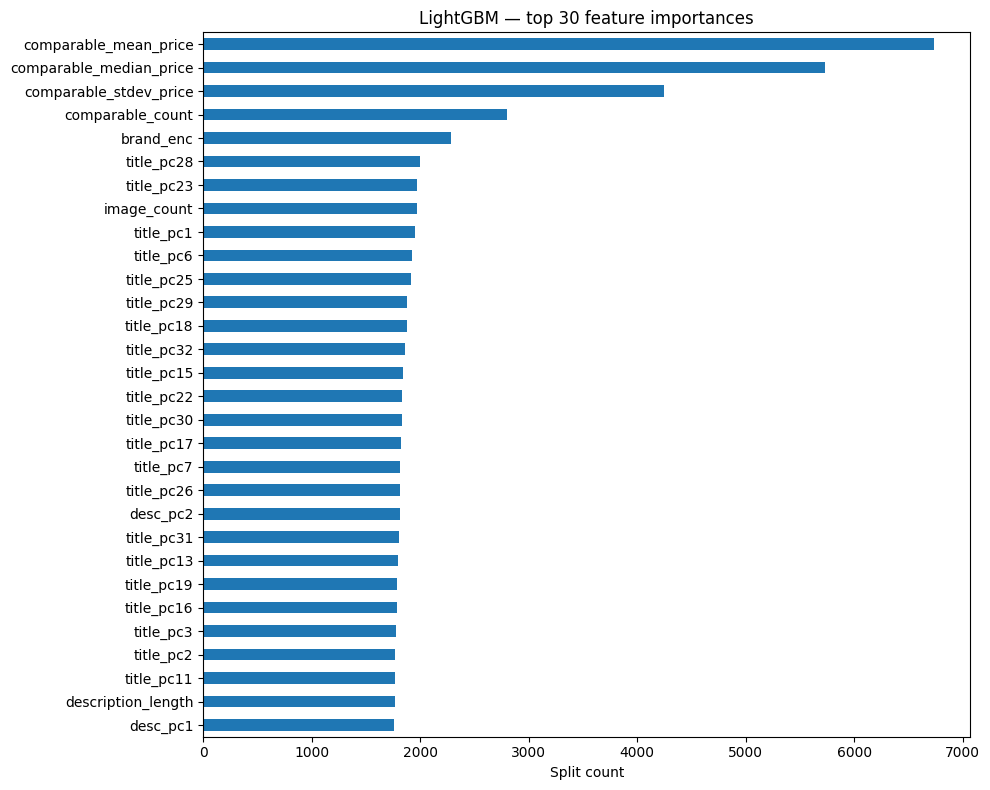

In [96]:
import lightgbm as lgb
import gc

gc.collect()

lgbm_model = lgb.LGBMRegressor(
    n_estimators=3000,
    learning_rate=0.05,
    max_depth=6,
    num_leaves=63,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_samples=10,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    verbose=-1,
)

lgbm_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[
        lgb.early_stopping(50, verbose=False),
        lgb.log_evaluation(100),
    ],
)

# ── Predictions ───────────────────────────────────────────────────────
y_pred_log_lgbm = lgbm_model.predict(X_val)
y_pred_usd_lgbm = np.expm1(y_pred_log_lgbm)
y_true_usd_lgbm = np.expm1(y_val)

# ── Overall metrics ───────────────────────────────────────────────────
rmse_log_lgbm = np.sqrt(mean_squared_error(y_val, y_pred_log_lgbm))
rmse_usd_lgbm = np.sqrt(mean_squared_error(y_true_usd_lgbm, y_pred_usd_lgbm))
mae_usd_lgbm  = mean_absolute_error(y_true_usd_lgbm, y_pred_usd_lgbm)
r2_lgbm       = r2_score(y_val, y_pred_log_lgbm)
mape_lgbm     = np.mean(np.abs((y_true_usd_lgbm - y_pred_usd_lgbm) / (y_true_usd_lgbm + 1e-9))) * 100
within20_lgbm = np.mean(np.abs((y_true_usd_lgbm - y_pred_usd_lgbm) / (y_true_usd_lgbm + 1e-9)) <= 0.20) * 100

print("\n── LightGBM ───────────────────────────────────────────")
print(f"  Best iteration:   {lgbm_model.best_iteration_}")
print(f"  RMSE (log scale): {rmse_log_lgbm:.4f}")
print(f"  RMSE (USD):       ${rmse_usd_lgbm:.2f}")
print(f"  MAE  (USD):       ${mae_usd_lgbm:.2f}")
print(f"  MAPE:             {mape_lgbm:.1f}%")
print(f"  R²   (log scale): {r2_lgbm:.4f}")
print(f"  Within 20%:       {within20_lgbm:.1f}% of predictions")

# ── Three-way comparison table ─────────────────────────────────────────
print("\n── RF vs XGBoost vs LightGBM ──────────────────────────")
header = f"  {"Metric":<20} {"RF":>8} {"XGBoost":>10} {"LightGBM":>10}"
print(header)
print(f"  {"-"*52}")
comparisons = [
    ("RMSE log",   rmse_log,  rmse_log_xgb,  rmse_log_lgbm),
    ("RMSE USD",   rmse_usd,  rmse_usd_xgb,  rmse_usd_lgbm),
    ("MAE USD",    mae_usd,   mae_usd_xgb,   mae_usd_lgbm),
    ("MAPE %",     mape,      mape_xgb,      mape_lgbm),
    ("R2",         r2,        r2_xgb,        r2_lgbm),
    ("Within 20%", within_20, within20_xgb,  within20_lgbm),
]
for label, rf_val, xgb_val, lgbm_val in comparisons:
    print(f"  {label:<20} {rf_val:>8.3f} {xgb_val:>10.3f} {lgbm_val:>10.3f}")

# ── Per-category breakdown ─────────────────────────────────────────────
val_df_lgbm = model_df.iloc[idx_val][["category", "sale_price"]].copy()
val_df_lgbm["pred_usd"] = y_pred_usd_lgbm
val_df_lgbm["true_usd"] = y_true_usd_lgbm

cat_metrics_lgbm = (
    val_df_lgbm.groupby("category")
    .apply(lambda g: pd.Series({
        "n":         len(g),
        "RMSE_USD":  np.sqrt(mean_squared_error(g["true_usd"], g["pred_usd"])),
        "MAE_USD":   mean_absolute_error(g["true_usd"], g["pred_usd"]),
        "MAPE_%":    np.mean(np.abs((g["true_usd"] - g["pred_usd"]) / (g["true_usd"] + 1e-9))) * 100,
        "Within20%": np.mean(np.abs((g["true_usd"] - g["pred_usd"]) / (g["true_usd"] + 1e-9)) <= 0.20) * 100,
    }), include_groups=False)
    .sort_values("RMSE_USD", ascending=False)
    .round(2)
)
print("\nPer-category breakdown:")
print(cat_metrics_lgbm.to_string())

# ── Predicted vs actual + residuals ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_true_usd_lgbm, y_pred_usd_lgbm, alpha=0.3, s=8)
lim = max(y_true_usd_lgbm.max(), y_pred_usd_lgbm.max())
axes[0].plot([0, lim], [0, lim], "r--", linewidth=1)
axes[0].set_xlabel("Actual price (USD)")
axes[0].set_ylabel("Predicted price (USD)")
axes[0].set_title(f"LightGBM — predicted vs actual\nRMSE=${rmse_usd_lgbm:.2f}, MAPE={mape_lgbm:.1f}%")

residuals_lgbm = y_pred_usd_lgbm - y_true_usd_lgbm
axes[1].hist(residuals_lgbm.clip(-300, 300), bins=60, edgecolor="none")
axes[1].axvline(0, color="red", linestyle="--")
axes[1].set_xlabel("Residual (pred − actual) USD")
axes[1].set_ylabel("Count")
axes[1].set_title("Residual distribution (clipped at ±$300)")

plt.tight_layout()
plt.show()

# ── Feature importance (top 30) ───────────────────────────────────────
importances_lgbm = pd.Series(lgbm_model.feature_importances_, index=FEATURE_COLS)
top30_lgbm = importances_lgbm.sort_values(ascending=False).head(30)

plt.figure(figsize=(10, 8))
top30_lgbm.sort_values().plot(kind="barh")
plt.title("LightGBM — top 30 feature importances")
plt.xlabel("Split count")
plt.tight_layout()
plt.show()

## Neural Network (MLP)

A four-layer feedforward network trained on the same feature matrix as the tree models.
Key differences from gradient boosting:

* **Feature scaling** — tree models are scale-invariant; the MLP requires `StandardScaler` fitted on training rows only.
* **Batch Norm + Dropout** — stabilise training and act as regularisation against overfitting.
* **Early stopping** — val-RMSE monitored every epoch; training halts after 20 non-improving epochs and the best weights are restored.
* **Optimiser** — Adam with `ReduceLROnPlateau` (halves LR after 10 epochs of no improvement).

Architecture: `n_features → 512 → 256 → 128 → 64 → 1`  
Activation: ReLU after each hidden layer (BatchNorm before activation).  
Target: `log(price + 1)` — same as every other model.

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler
import gc

gc.collect()

# ── Device ────────────────────────────────────────────────────────────
device = (
    torch.device("mps")  if torch.backends.mps.is_available() else
    torch.device("cuda") if torch.cuda.is_available()          else
    torch.device("cpu")
)
print(f"Using device: {device}")

# ── Scale features (fit on train only) ───────────────────────────────
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train).astype(np.float32)
X_val_sc   = scaler.transform(X_val).astype(np.float32)

# ── Torch tensors ─────────────────────────────────────────────────────
t_X_train = torch.from_numpy(X_train_sc).to(device)
t_y_train = torch.from_numpy(y_train.astype(np.float32)).unsqueeze(1).to(device)
t_X_val   = torch.from_numpy(X_val_sc).to(device)
t_y_val   = torch.from_numpy(y_val.astype(np.float32)).unsqueeze(1).to(device)

train_loader = DataLoader(
    TensorDataset(t_X_train, t_y_train),
    batch_size=512,
    shuffle=True,
)

# ── Model definition ──────────────────────────────────────────────────
def make_block(in_dim, out_dim, dropout_p):
    return nn.Sequential(
        nn.Linear(in_dim, out_dim),
        nn.BatchNorm1d(out_dim),
        nn.ReLU(),
        nn.Dropout(dropout_p),
    )

class PriceMLP(nn.Module):
    def __init__(self, n_features):
        super().__init__()
        self.net = nn.Sequential(
            make_block(n_features, 512, 0.30),
            make_block(512,        256, 0.25),
            make_block(256,        128, 0.20),
            make_block(128,         64, 0.10),
            nn.Linear(64, 1),
        )
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity="relu")
                nn.init.zeros_(m.bias)

    def forward(self, x):
        return self.net(x)

mlp = PriceMLP(X_train_sc.shape[1]).to(device)
total_params = sum(p.numel() for p in mlp.parameters() if p.requires_grad)
print(f"Parameters: {total_params:,}")

# ── Training loop ─────────────────────────────────────────────────────
criterion  = nn.MSELoss()
optimiser  = torch.optim.Adam(mlp.parameters(), lr=1e-3, weight_decay=1e-5)
scheduler  = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimiser, mode="min", factor=0.5, patience=10, verbose=False
)

MAX_EPOCHS  = 200
ES_PATIENCE = 20

best_val_loss  = float("inf")
best_state     = None
patience_count = 0
train_losses   = []
val_losses     = []

for epoch in range(1, MAX_EPOCHS + 1):
    mlp.train()
    epoch_loss = 0.0
    for xb, yb in train_loader:
        optimiser.zero_grad()
        loss = criterion(mlp(xb), yb)
        loss.backward()
        nn.utils.clip_grad_norm_(mlp.parameters(), max_norm=1.0)
        optimiser.step()
        epoch_loss += loss.item() * len(xb)
    train_losses.append(epoch_loss / len(t_X_train))

    mlp.eval()
    with torch.no_grad():
        val_loss = criterion(mlp(t_X_val), t_y_val).item()
    val_losses.append(val_loss)
    scheduler.step(val_loss)

    if val_loss < best_val_loss:
        best_val_loss  = val_loss
        best_state     = {k: v.cpu().clone() for k, v in mlp.state_dict().items()}
        patience_count = 0
    else:
        patience_count += 1
        if patience_count >= ES_PATIENCE:
            print(f"Early stopping at epoch {epoch}  (best val RMSE(log)={best_val_loss**0.5:.4f})")
            break

    if epoch % 20 == 0:
        lr_now = optimiser.param_groups[0]["lr"]
        print(f"  Epoch {epoch:3d} | train RMSE(log)={train_losses[-1]**0.5:.4f} "
              f"| val RMSE(log)={val_loss**0.5:.4f} | lr={lr_now:.2e}")

mlp.load_state_dict(best_state)

# ── Learning curve ────────────────────────────────────────────────────
plt.figure(figsize=(8, 3))
plt.plot([l**0.5 for l in train_losses], label="train RMSE", linewidth=1)
plt.plot([l**0.5 for l in val_losses],   label="val RMSE",   linewidth=1)
plt.xlabel("Epoch"); plt.ylabel("RMSE (log scale)")
plt.title("MLP training curve")
plt.legend(); plt.tight_layout(); plt.show()

# ── Predictions ───────────────────────────────────────────────────────
mlp.eval()
with torch.no_grad():
    y_pred_log_nn = mlp(t_X_val).cpu().numpy().squeeze()
y_pred_usd_nn = np.expm1(y_pred_log_nn)
y_true_usd_nn = np.expm1(y_val)

# ── Overall metrics ───────────────────────────────────────────────────
rmse_log_nn = np.sqrt(mean_squared_error(y_val, y_pred_log_nn))
rmse_usd_nn = np.sqrt(mean_squared_error(y_true_usd_nn, y_pred_usd_nn))
mae_usd_nn  = mean_absolute_error(y_true_usd_nn, y_pred_usd_nn)
r2_nn       = r2_score(y_val, y_pred_log_nn)
mape_nn     = np.mean(np.abs((y_true_usd_nn - y_pred_usd_nn) / (y_true_usd_nn + 1e-9))) * 100
within20_nn = np.mean(np.abs((y_true_usd_nn - y_pred_usd_nn) / (y_true_usd_nn + 1e-9)) <= 0.20) * 100

print("\n── Neural Network (MLP) ───────────────────────────────")
print(f"  RMSE (log scale): {rmse_log_nn:.4f}")
print(f"  RMSE (USD):       ${rmse_usd_nn:.2f}")
print(f"  MAE  (USD):       ${mae_usd_nn:.2f}")
print(f"  MAPE:             {mape_nn:.1f}%")
print(f"  R²   (log scale): {r2_nn:.4f}")
print(f"  Within 20%:       {within20_nn:.1f}%")

# ── Four-way comparison table ──────────────────────────────────────────
print("\n── RF vs XGBoost vs LightGBM vs MLP ──────────────────")
print(f"  {'Metric':<20} {'RF':>8} {'XGBoost':>10} {'LightGBM':>10} {'MLP':>8}")
print(f"  {'-'*60}")
comparisons = [
    ("RMSE log",   rmse_log,  rmse_log_xgb,  rmse_log_lgbm,  rmse_log_nn),
    ("RMSE USD",   rmse_usd,  rmse_usd_xgb,  rmse_usd_lgbm,  rmse_usd_nn),
    ("MAE USD",    mae_usd,   mae_usd_xgb,   mae_usd_lgbm,   mae_usd_nn),
    ("MAPE %",     mape,      mape_xgb,      mape_lgbm,      mape_nn),
    ("R2",         r2,        r2_xgb,        r2_lgbm,        r2_nn),
    ("Within 20%", within_20, within20_xgb,  within20_lgbm,  within20_nn),
]
for label, rf_v, xgb_v, lgbm_v, nn_v in comparisons:
    print(f"  {label:<20} {rf_v:>8.3f} {xgb_v:>10.3f} {lgbm_v:>10.3f} {nn_v:>8.3f}")

# ── Per-category breakdown ─────────────────────────────────────────────
val_df_nn = model_df.iloc[idx_val][["category", "sale_price"]].copy()
val_df_nn["pred_usd"] = y_pred_usd_nn
val_df_nn["true_usd"] = y_true_usd_nn

cat_metrics_nn = (
    val_df_nn.groupby("category")
    .apply(lambda g: pd.Series({
        "n":         len(g),
        "RMSE_USD":  np.sqrt(mean_squared_error(g["true_usd"], g["pred_usd"])),
        "MAE_USD":   mean_absolute_error(g["true_usd"], g["pred_usd"]),
        "MAPE_%":    np.mean(np.abs((g["true_usd"] - g["pred_usd"]) / (g["true_usd"] + 1e-9))) * 100,
        "Within20%": np.mean(np.abs((g["true_usd"] - g["pred_usd"]) / (g["true_usd"] + 1e-9)) <= 0.20) * 100,
    }), include_groups=False)
    .sort_values("RMSE_USD", ascending=False)
    .round(2)
)
print("\nPer-category breakdown:")
print(cat_metrics_nn.to_string())

# ── Predicted vs actual + residuals ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_true_usd_nn, y_pred_usd_nn, alpha=0.3, s=8)
lim = max(y_true_usd_nn.max(), y_pred_usd_nn.max())
axes[0].plot([0, lim], [0, lim], "r--", linewidth=1)
axes[0].set_xlabel("Actual price (USD)")
axes[0].set_ylabel("Predicted price (USD)")
axes[0].set_title(f"MLP — predicted vs actual\nRMSE=${rmse_usd_nn:.2f}, MAPE={mape_nn:.1f}%")

residuals_nn = y_pred_usd_nn - y_true_usd_nn
axes[1].hist(residuals_nn.clip(-300, 300), bins=60, edgecolor="none")
axes[1].axvline(0, color="red", linestyle="--")
axes[1].set_xlabel("Residual (pred − actual) USD")
axes[1].set_ylabel("Count")
axes[1].set_title("Residual distribution (clipped at ±$300)")

plt.tight_layout()
plt.show()

# ── Cleanup GPU/MPS memory ─────────────────────────────────────────────
del t_X_train, t_y_train, t_X_val, t_y_val, X_train_sc, X_val_sc
gc.collect()
if device.type == "mps":
    torch.mps.empty_cache()
elif device.type == "cuda":
    torch.cuda.empty_cache()
print("Done.")


## Optuna hyperparameter tuning — LightGBM + 5-fold stratified CV

Each Optuna trial trains LightGBM with 5-fold stratified CV (stratified on category).
The objective is the mean val RMSE on log(price+1) across all folds.

**Note:** target encoding and comparable stats were fitted on the full dataset,
so CV scores are slightly optimistic for those features. The tuning is still
valid for selecting hyperparameters — just don't treat the CV RMSE as an
unbiased generalisation estimate.

  0%|          | 0/60 [00:00<?, ?it/s]/Users/kevin/Programming/multi-agentic-sales-representative-system/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/kevin/Programming/multi-agentic-sales-representative-system/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/kevin/Programming/multi-agentic-sales-representative-system/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/kevin/Programming/multi-agentic-sales-representative-system/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was f


Best CV RMSE (log scale): 0.6193
Best params:
  learning_rate: 0.04591984089308779
  max_depth: 10
  num_leaves: 175
  subsample: 0.9585153182564305
  colsample_bytree: 0.8786976019123933
  min_child_samples: 5
  reg_alpha: 0.002882982346234177
  reg_lambda: 0.8082000815931292
[100]	valid_0's l2: 0.494654
[200]	valid_0's l2: 0.455011
[300]	valid_0's l2: 0.426725
[400]	valid_0's l2: 0.413571
[500]	valid_0's l2: 0.406056
[600]	valid_0's l2: 0.401185
[700]	valid_0's l2: 0.396953
[800]	valid_0's l2: 0.394723
[900]	valid_0's l2: 0.392471
[1000]	valid_0's l2: 0.390006
[1100]	valid_0's l2: 0.389016
[1200]	valid_0's l2: 0.387841
[1300]	valid_0's l2: 0.386765
[1400]	valid_0's l2: 0.386499
[1500]	valid_0's l2: 0.385954
[1600]	valid_0's l2: 0.38573
[1700]	valid_0's l2: 0.385442
[1800]	valid_0's l2: 0.385097
[1900]	valid_0's l2: 0.384973
[2000]	valid_0's l2: 0.38488
[2100]	valid_0's l2: 0.384738
[2200]	valid_0's l2: 0.384557
[2300]	valid_0's l2: 0.38451
[2400]	valid_0's l2: 0.384453


/Users/kevin/Programming/multi-agentic-sales-representative-system/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(



── LightGBM baseline vs tuned ─────────────────────────
  Metric                 Baseline      Tuned      Delta
  ------------------------------------------------------
  RMSE log                  0.627      0.620    -0.007
  RMSE USD                177.731    175.251    -2.480
  MAE USD                  60.785     58.412    -2.373
  MAPE %                   64.178     63.492    -0.686
  R2                        0.785      0.790 +    0.005
  Within 20%               35.701     38.524 +    2.822


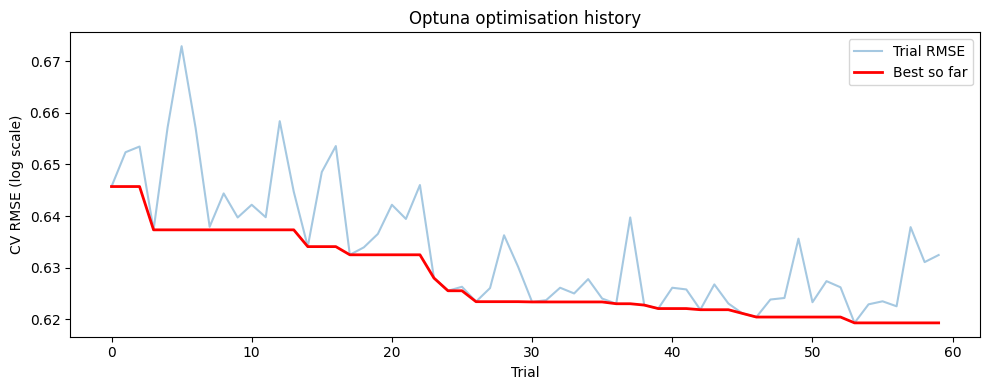

In [97]:
import optuna
import lightgbm as lgb
import gc
from sklearn.model_selection import StratifiedKFold

optuna.logging.set_verbosity(optuna.logging.WARNING)
gc.collect()

X_all      = model_df[FEATURE_COLS].values
y_all      = model_df[TARGET_COL].values
groups_all = model_df["category"].values

N_FOLDS  = 5
N_TRIALS = 60

def objective(trial):
    params = {
        "n_estimators":      3000,
        "learning_rate":     trial.suggest_float("learning_rate", 0.01, 0.15, log=True),
        "max_depth":         trial.suggest_int("max_depth", 4, 10),
        "num_leaves":        trial.suggest_int("num_leaves", 15, 255),
        "subsample":         trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree":  trial.suggest_float("colsample_bytree", 0.4, 1.0),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 50),
        "reg_alpha":         trial.suggest_float("reg_alpha", 1e-3, 10.0, log=True),
        "reg_lambda":        trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
        "random_state":      42,
        "n_jobs":            -1,
        "verbose":           -1,
    }

    skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)
    fold_rmses = []

    for train_idx, val_idx in skf.split(X_all, groups_all):
        X_tr, X_vl = X_all[train_idx], X_all[val_idx]
        y_tr, y_vl = y_all[train_idx], y_all[val_idx]

        m = lgb.LGBMRegressor(**params)
        m.fit(
            X_tr, y_tr,
            eval_set=[(X_vl, y_vl)],
            callbacks=[
                lgb.early_stopping(50, verbose=False),
                lgb.log_evaluation(-1),
            ],
        )
        preds = m.predict(X_vl)
        fold_rmses.append(np.sqrt(mean_squared_error(y_vl, preds)))

    return float(np.mean(fold_rmses))


study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

print(f"\nBest CV RMSE (log scale): {study.best_value:.4f}")
print("Best params:")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")

# ── Retrain on full train split with best params ───────────────────────
best_params = study.best_params | {
    "n_estimators": 3000,
    "random_state": 42,
    "n_jobs": -1,
    "verbose": -1,
}

lgbm_tuned = lgb.LGBMRegressor(**best_params)
lgbm_tuned.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[
        lgb.early_stopping(50, verbose=False),
        lgb.log_evaluation(100),
    ],
)

y_pred_tuned     = lgbm_tuned.predict(X_val)
y_pred_usd_tuned = np.expm1(y_pred_tuned)
y_true_usd_tuned = np.expm1(y_val)

rmse_log_tuned = np.sqrt(mean_squared_error(y_val, y_pred_tuned))
rmse_usd_tuned = np.sqrt(mean_squared_error(y_true_usd_tuned, y_pred_usd_tuned))
mae_usd_tuned  = mean_absolute_error(y_true_usd_tuned, y_pred_usd_tuned)
r2_tuned       = r2_score(y_val, y_pred_tuned)
mape_tuned     = np.mean(np.abs((y_true_usd_tuned - y_pred_usd_tuned) / (y_true_usd_tuned + 1e-9))) * 100
within20_tuned = np.mean(np.abs((y_true_usd_tuned - y_pred_usd_tuned) / (y_true_usd_tuned + 1e-9)) <= 0.20) * 100

print("\n── LightGBM baseline vs tuned ─────────────────────────")
header = f"  {"Metric":<20} {"Baseline":>10} {"Tuned":>10} {"Delta":>10}"
print(header)
print(f"  {"-"*54}")
for label, base_val, tuned_val in [
    ("RMSE log",   rmse_log_lgbm,  rmse_log_tuned),
    ("RMSE USD",   rmse_usd_lgbm,  rmse_usd_tuned),
    ("MAE USD",    mae_usd_lgbm,   mae_usd_tuned),
    ("MAPE %",     mape_lgbm,      mape_tuned),
    ("R2",         r2_lgbm,        r2_tuned),
    ("Within 20%", within20_lgbm,  within20_tuned),
]:
    delta = tuned_val - base_val
    sign  = "+" if delta > 0 else ""
    print(f"  {label:<20} {base_val:>10.3f} {tuned_val:>10.3f} {sign}{delta:>9.3f}")

# ── Optuna optimisation history plot ──────────────────────────────────
trials_df = study.trials_dataframe()
plt.figure(figsize=(10, 4))
plt.plot(trials_df["number"], trials_df["value"], alpha=0.4, label="Trial RMSE")
plt.plot(
    trials_df["number"],
    trials_df["value"].cummin(),
    color="red", linewidth=2, label="Best so far",
)
plt.xlabel("Trial")
plt.ylabel("CV RMSE (log scale)")
plt.title("Optuna optimisation history")
plt.legend()
plt.tight_layout()
plt.show()

## Save tuned model

Persist the tuned LightGBM model and its metadata (feature list, best hyperparameters, validation metrics) so the pricing agent can reload them without retraining.

In [98]:
import pickle
import json
import os

MODEL_DIR      = "../packages/ml"
MODEL_PATH     = os.path.join(MODEL_DIR, "pricing_model_v3.pkl")
META_PATH      = os.path.join(MODEL_DIR, "pricing_model_v3_meta.json")
PCA_TITLE_PATH = os.path.join(MODEL_DIR, "pca_title_v3.pkl")
PCA_DESC_PATH  = os.path.join(MODEL_DIR, "pca_desc_v3.pkl")

# Save LightGBM model
with open(MODEL_PATH, "wb") as fh:
    pickle.dump(lgbm_tuned, fh)

# Save PCA objects (needed at inference to project new embeddings)
with open(PCA_TITLE_PATH, "wb") as fh:
    pickle.dump(pca, fh)
with open(PCA_DESC_PATH, "wb") as fh:
    pickle.dump(pca_desc, fh)

# Build inference-time target encoding lookups (smoothed means on full dataset)
SMOOTHING   = 10
global_mean = clean["log_price"].mean()

def _build_enc_lookup(df, col):
    stats = df.groupby(col)["log_price"].agg(["mean", "count"])
    stats["smoothed"] = (
        (stats["count"] * stats["mean"] + SMOOTHING * global_mean)
        / (stats["count"] + SMOOTHING)
    )
    return stats["smoothed"].to_dict()

brand_enc_lookup    = _build_enc_lookup(clean, "brand_clean")
category_enc_lookup = _build_enc_lookup(clean, "category")

model_meta = {
    "feature_cols": FEATURE_COLS,
    "target_col": TARGET_COL,
    "sentence_model_name": "all-MiniLM-L6-v2",
    "n_title_pcs": int(pca.n_components_),
    "n_desc_pcs":  int(pca_desc.n_components_),
    "best_params": study.best_params,
    "val_metrics": {
        "rmse_log":      round(rmse_log_tuned, 4),
        "rmse_usd":      round(rmse_usd_tuned, 4),
        "mae_usd":       round(mae_usd_tuned,  4),
        "mape_pct":      round(mape_tuned,     4),
        "r2":            round(r2_tuned,       4),
        "within_20_pct": round(within20_tuned, 4),
    },
    "inference_encodings": {
        "brand":                {str(k): float(v) for k, v in brand_enc_lookup.items()},
        "brand_global_mean":    float(global_mean),
        "category":             {str(k): float(v) for k, v in category_enc_lookup.items()},
        "category_global_mean": float(global_mean),
    },
}

with open(META_PATH, "w") as fh:
    json.dump(model_meta, fh, indent=2)

print(f"Saved: {MODEL_PATH}")
print(f"Saved: {META_PATH}")
print(f"Saved: {PCA_TITLE_PATH}  ({pca.n_components_} title PCs)")
print(f"Saved: {PCA_DESC_PATH}   ({pca_desc.n_components_} desc PCs)")
print(f"  Features        : {len(FEATURE_COLS)}")
print(f"  Brand lookups   : {len(brand_enc_lookup)}")
print(f"  Category lookups: {len(category_enc_lookup)}")


Saved: ../packages/ml/pricing_model_v3.pkl
Saved: ../packages/ml/pricing_model_v3_meta.json
Saved: ../packages/ml/pca_title_v3.pkl  (32 title PCs)
Saved: ../packages/ml/pca_desc_v3.pkl   (32 desc PCs)
  Features        : 78
  Brand lookups   : 5635
  Category lookups: 14


## Recovery — retrain tuned model from saved hyperparameters

The `.pkl` can be lost if the kernel exits before the OS flushes the write buffer.
This cell retrains LightGBM from scratch using the best hyperparameters already
saved in `pricing_model_v3_meta.json` — takes ~10–15 min, no Optuna re-run needed.

In [1]:
import pickle, json, os
import pandas as pd
import numpy as np
import lightgbm as lgb
import gc
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

MODEL_DIR  = "../packages/ml"
META_PATH  = os.path.join(MODEL_DIR, "pricing_model_v3_meta.json")
MODEL_PATH = os.path.join(MODEL_DIR, "pricing_model_v3.pkl")

# ── Load saved best params ─────────────────────────────────────────────
with open(META_PATH) as f:
    meta = json.load(f)

best_params   = meta["best_params"]
FEATURE_COLS  = meta["feature_cols"]
TARGET_COL    = meta["target_col"]
print("Best params:", json.dumps(best_params, indent=2))

# ── Reload feature matrix ──────────────────────────────────────────────
model_df = pd.read_parquet("output/model_ready.parquet")
cat_counts = model_df["category"].value_counts()
model_df = model_df[model_df["category"].isin(cat_counts[cat_counts >= 2].index)].copy()

X = model_df[FEATURE_COLS].values
y = model_df[TARGET_COL].values

X_train, X_val, y_train, y_val, idx_train, idx_val = train_test_split(
    X, y, np.arange(len(model_df)),
    test_size=0.2,
    random_state=42,
    stratify=model_df["category"].values,
)
print(f"Train: {len(X_train):,}  |  Val: {len(X_val):,}  |  Features: {X_train.shape[1]}")

# ── Retrain with saved best params ─────────────────────────────────────
lgbm_tuned = lgb.LGBMRegressor(
    n_estimators=5000,
    early_stopping_round=100,
    random_state=42,
    n_jobs=-1,
    verbose=-1,
    **best_params,
)
lgbm_tuned.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[lgb.log_evaluation(200)],
)
print(f"\nBest iteration: {lgbm_tuned.best_iteration_}")

# ── Evaluate ───────────────────────────────────────────────────────────
y_pred_log = lgbm_tuned.predict(X_val)
y_pred_usd = np.expm1(y_pred_log)
y_true_usd = np.expm1(y_val)

rmse_log_tuned  = np.sqrt(mean_squared_error(y_val, y_pred_log))
rmse_usd_tuned  = np.sqrt(mean_squared_error(y_true_usd, y_pred_usd))
mae_usd_tuned   = mean_absolute_error(y_true_usd, y_pred_usd)
r2_tuned        = r2_score(y_val, y_pred_log)
mape_tuned      = np.mean(np.abs((y_true_usd - y_pred_usd) / (y_true_usd + 1e-9))) * 100
within20_tuned  = np.mean(np.abs((y_true_usd - y_pred_usd) / (y_true_usd + 1e-9)) <= 0.20) * 100

print("\n── Recovered tuned LightGBM ───────────────────────────")
print(f"  RMSE (log scale): {rmse_log_tuned:.4f}")
print(f"  RMSE (USD):       ${rmse_usd_tuned:.2f}")
print(f"  MAE  (USD):       ${mae_usd_tuned:.2f}")
print(f"  MAPE:             {mape_tuned:.1f}%")
print(f"  R²   (log scale): {r2_tuned:.4f}")
print(f"  Within 20%:       {within20_tuned:.1f}%")

# ── Save model ─────────────────────────────────────────────────────────
with open(MODEL_PATH, "wb") as fh:
    pickle.dump(lgbm_tuned, fh)

# Verify the write actually landed
size_kb = os.path.getsize(MODEL_PATH) / 1024
if size_kb < 1:
    raise RuntimeError(f"pkl is suspiciously small ({size_kb:.1f} KB) — write may have failed")

print(f"\nSaved {MODEL_PATH}  ({size_kb:.0f} KB)")

# Update val_metrics in meta with fresh numbers
meta["val_metrics"] = {
    "rmse_log":      round(float(rmse_log_tuned),  4),
    "rmse_usd":      round(float(rmse_usd_tuned),  4),
    "mae_usd":       round(float(mae_usd_tuned),   4),
    "mape_pct":      round(float(mape_tuned),       4),
    "r2":            round(float(r2_tuned),         4),
    "within_20_pct": round(float(within20_tuned),   4),
}
with open(META_PATH, "w") as fh:
    json.dump(meta, fh, indent=2)
print(f"Updated {META_PATH}")

gc.collect()


Best params: {
  "learning_rate": 0.04591984089308779,
  "max_depth": 10,
  "num_leaves": 175,
  "subsample": 0.9585153182564305,
  "colsample_bytree": 0.8786976019123933,
  "min_child_samples": 5,
  "reg_alpha": 0.002882982346234177,
  "reg_lambda": 0.8082000815931292
}
Train: 33,159  |  Val: 8,290  |  Features: 78
[200]	valid_0's l2: 0.502451
[400]	valid_0's l2: 0.459962
[600]	valid_0's l2: 0.448086
[800]	valid_0's l2: 0.44278
[1000]	valid_0's l2: 0.43993
[1200]	valid_0's l2: 0.438709
[1400]	valid_0's l2: 0.437901
[1600]	valid_0's l2: 0.437359
[1800]	valid_0's l2: 0.436739
[2000]	valid_0's l2: 0.436474
[2200]	valid_0's l2: 0.436304
[2400]	valid_0's l2: 0.436168
[2600]	valid_0's l2: 0.436113

Best iteration: 2635


/Users/kevin/Programming/multi-agentic-sales-representative-system/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(



── Recovered tuned LightGBM ───────────────────────────
  RMSE (log scale): 0.6604
  RMSE (USD):       $173.40
  MAE  (USD):       $62.11
  MAPE:             78.6%
  R²   (log scale): 0.7607
  Within 20%:       35.0%

Saved ../packages/ml/pricing_model_v3.pkl  (44827 KB)
Updated ../packages/ml/pricing_model_v3_meta.json


74

## Price calibration — per-category floor/ceiling

The model can predict outside the observed price range for a category (especially on thin-data categories like Sports). A simple clip to the 5th/95th percentile of *training* prices per category is a zero-parameter post-processing step that can tighten MAE and improve Within 20%.

In [2]:
# ── Build per-category price bounds from training data ───────────────
train_sub = model_df.iloc[idx_train].copy()
train_sub["price_usd"] = np.expm1(y_train)

cat_bounds = (
    train_sub.groupby("category")["price_usd"]
    .agg(floor=lambda x: x.quantile(0.05), ceiling=lambda x: x.quantile(0.95))
    .to_dict("index")
)

# ── Apply calibration to val predictions ──────────────────────────────
val_cats    = model_df.iloc[idx_val]["category"].values
y_pred_cal  = y_pred_usd_tuned.copy()

for i, cat in enumerate(val_cats):
    if cat in cat_bounds:
        y_pred_cal[i] = np.clip(y_pred_cal[i], cat_bounds[cat]["floor"], cat_bounds[cat]["ceiling"])

# ── Metrics ────────────────────────────────────────────────────────────
rmse_cal     = np.sqrt(mean_squared_error(y_true_usd_tuned, y_pred_cal))
mae_cal      = mean_absolute_error(y_true_usd_tuned, y_pred_cal)
mape_cal     = np.mean(np.abs((y_true_usd_tuned - y_pred_cal) / (y_true_usd_tuned + 1e-9))) * 100
within20_cal = np.mean(np.abs((y_true_usd_tuned - y_pred_cal) / (y_true_usd_tuned + 1e-9)) <= 0.20) * 100

col_w = 12
header = f"  {'Metric':<20} {'Tuned':>{col_w}} {'Calibrated':>{col_w}} {'Delta':>{col_w}}"
print("\n── Tuned vs Tuned+Calibration ──────────────────────────")
print(header)
print(f"  {'-'*58}")
for label, base_val, cal_val in [
    ("RMSE USD",   rmse_usd_tuned,  rmse_cal),
    ("MAE USD",    mae_usd_tuned,   mae_cal),
    ("MAPE %",     mape_tuned,      mape_cal),
    ("Within 20%", within20_tuned,  within20_cal),
]:
    delta = cal_val - base_val
    sign  = "+" if delta > 0 else ""
    print(f"  {label:<20} {base_val:>{col_w}.3f} {cal_val:>{col_w}.3f} {sign}{delta:>9.3f}")

# ── Per-category breakdown ─────────────────────────────────────────────
val_df = model_df.iloc[idx_val].copy()
val_df["pred_tuned"] = y_pred_usd_tuned
val_df["pred_cal"]   = y_pred_cal
val_df["actual"]     = y_true_usd_tuned

per_cat = []
for cat, grp in val_df.groupby("category"):
    w20_t = np.mean(np.abs((grp["actual"] - grp["pred_tuned"]) / (grp["actual"] + 1e-9)) <= 0.20) * 100
    w20_c = np.mean(np.abs((grp["actual"] - grp["pred_cal"]) / (grp["actual"] + 1e-9)) <= 0.20) * 100
    per_cat.append({"category": cat, "n": len(grp), "Within20_Tuned": round(w20_t, 1), "Within20_Cal": round(w20_c, 1), "Delta": round(w20_c - w20_t, 1)})

per_cat_df = pd.DataFrame(per_cat).sort_values("Delta", ascending=False)
print("\nPer-category Within 20%:")
print(per_cat_df.to_string(index=False))

# ── Save cat_bounds into metadata if calibration helps overall ──────────
if within20_cal > within20_tuned:
    with open(META_PATH) as fh:
        meta = json.load(fh)
    meta["cat_price_bounds"] = {k: {"floor": round(v["floor"], 2), "ceiling": round(v["ceiling"], 2)} for k, v in cat_bounds.items()}
    meta["val_metrics"]["within_20_calibrated"] = round(within20_cal, 4)
    with open(META_PATH, "w") as fh:
        json.dump(meta, fh, indent=2)
    print("\nCalibration helped — cat_bounds saved to lgbm_tuned_meta.json")
else:
    print("\nCalibration did not improve Within 20% overall — bounds not saved")


NameError: name 'y_pred_usd_tuned' is not defined